# Ý Tưởng:
- Bộ dữ liệu có những mã cổ phiếu đầu tiên xuất hiện từ năm 2012->2026
- Chia bộ dữ liệu làm 3 phần, mỗi phần 4 năm
- Dùng bộ dữ liệu đầu tiên để dự đoán bộ dữ liệu tiếp theo, sau đó tiếp theo dự đoán hiện tại
- Đánh theo dòng tiền 

**Ưu điểm**
- Dễ finetune vì đã xảy ra các kết quả rồi

**Nhược điểm**
- Năm 2012-2017: Là T+3, thanh khoản yếu, nhỏ lẻ ít. Năm 2018- đến nay: Là T+2.5, thanh khoản mạnh
- Năm 2012-2017: Là thời kỳ uptrend cứ volume lớn đặt lệnh là ăn, 2018-2021: Covid19 suy thoái => Khiến cho mô hình tưởng rằng cứ ở đáy đặt volume lớn là ăn
- Bị trễ đi chậm hơn so với thực tế 

**Khắc phục**
- Dùng chỉ số thị trường để xác định cùng
- Thử chuyển sang cửa số trượt động, mỗi quý train lại 3 năm gần nhất => Phù hợp lối đánh hiện nay


**Trước tiên**
- Quy tắc: Dòng tiền => Phân tích kỹ thuật => Thông tin => Quyết định mua/bán

**Các bước làm**
- Thu thập dữ liệu (Done)
- EDA (Done) 
- Data Processing and Feature Engineering ()
- Xây dựng mô hình ()

In [169]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [170]:
df_ck=pd.read_csv("Data/DataCK.csv")
df_ck

,Date,Ticker,Open,High,Low,Close,Volume
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0
...,...,...,...,...,...,...,...
29796,2026-03-13,VRE,25.60,26.00,25.25,25.25,3440100.0
29797,2026-03-16,VRE,25.25,25.90,25.10,25.90,4825600.0
29798,2026-03-17,VRE,26.00,26.90,25.90,26.45,5159000.0
29799,2026-03-18,VRE,26.50,26.95,26.10,26.10,3490200.0


In [171]:
df_ck["Date"]= pd.to_datetime(df_ck["Date"], format="%Y-%m-%d") # Định dạng cào qua api là năm/tháng/ngày

In [172]:
df_ck.info()

<class 'pandas.DataFrame'>
RangeIndex: 29801 entries, 0 to 29800
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    29801 non-null  datetime64[us]
 1   Ticker  29801 non-null  str           
 2   Open    29801 non-null  float64       
 3   High    29801 non-null  float64       
 4   Low     29801 non-null  float64       
 5   Close   29801 non-null  float64       
 6   Volume  29801 non-null  float64       
dtypes: datetime64[us](1), float64(5), str(1)
memory usage: 1.7 MB


# EDA

### Process VNINDEX and VN30

In [173]:
df_vnindex= pd.read_excel("Data/LichSuGia_VNINDEX_01_01_2021_03_19_2026.xlsx")
df_vnindex.head()

,Ngay,GiaDieuChinh,GiaDongCua,ThayDoi,KhoiLuongKhopLenh,GiaTriKhopLenh,KLThoaThuan,GtThoaThuan,GiaMoCua,GiaCaoNhat,GiaThapNhat
0,18/03/2026,"1713,83","1713,83","3,54(0,21 %)",698898800,21562750660000,129156598,3140468907500,"1718,3","1742,87","1703,4"
1,17/03/2026,"1710,29","1710,29","17,08(1,01 %)",724341700,7243417000000,148583440,3500824249450,"1709,38","1732,31","1707,5"
2,16/03/2026,"1693,21","1693,21","-3,03(-0,18 %)",745318200,20307816450000,123251364,2594949056180,"1701,06",1707,"1680,7"
3,13/03/2026,"1696,24","1696,24","-13,37(-0,78 %)",876840300,24701434140000,144178661,2659800839800,"1697,72","1716,75","1688,67"
4,12/03/2026,"1709,61","1709,61","-18,73(-1,08 %)",856853300,24424934290000,87959608,1883759307800,"1716,62","1725,52","1701,59"


In [174]:
df_vnindex.info()

<class 'pandas.DataFrame'>
RangeIndex: 1293 entries, 0 to 1292
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Ngay               1293 non-null   str  
 1   GiaDieuChinh       1293 non-null   str  
 2   GiaDongCua         1293 non-null   str  
 3   ThayDoi            1293 non-null   str  
 4   KhoiLuongKhopLenh  1293 non-null   int64
 5   GiaTriKhopLenh     1293 non-null   int64
 6   KLThoaThuan        1293 non-null   int64
 7   GtThoaThuan        1293 non-null   int64
 8   GiaMoCua           1293 non-null   str  
 9   GiaCaoNhat         1293 non-null   str  
 10  GiaThapNhat        1293 non-null   str  
dtypes: int64(4), str(7)
memory usage: 183.8 KB


In [175]:
def process(file_path, ticker):
    df= pd.read_excel(file_path)
    cols_to_keep= ["Ngay", "GiaMoCua", "GiaCaoNhat", "GiaThapNhat", "GiaDongCua", "KhoiLuongKhopLenh"]
    df= df[cols_to_keep].copy()
    df.columns= ["Date", "Open", "High", "Low", "Close", "Volume"]
    num_cols= ["Open", "High", "Low", "Close", "Volume"]
    for col in num_cols:
        df[col]= df[col].astype(str).str.replace(',', '.')
        df[col]= pd.to_numeric(df[col], errors="coerce")

    df["Date"]= pd.to_datetime(df["Date"], format="mixed", dayfirst=True) # Định dạng excel là ngày/tháng/năm
    df["Ticker"]= ticker
    df= df[["Date", "Ticker", "Open", "High", "Low", "Close", "Volume"]]
    df= df.sort_values("Date").reset_index(drop=True)
    return df

file_vnindex= "Data/LichSuGia_VNINDEX_01_01_2021_03_19_2026.xlsx"
file_vn30= "Data/LichSuGia_VN30INDEX_01_01_2021_03_19_2026.xlsx"

df_vnindex= process(file_vnindex, "VNINDEX")
df_vn30= process(file_vn30, "VN30")

print(df_vnindex.info())

<class 'pandas.DataFrame'>
RangeIndex: 1293 entries, 0 to 1292
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1293 non-null   datetime64[us]
 1   Ticker  1293 non-null   str           
 2   Open    1293 non-null   float64       
 3   High    1293 non-null   float64       
 4   Low     1293 non-null   float64       
 5   Close   1293 non-null   float64       
 6   Volume  1293 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 79.8 KB
None


In [176]:
df_concat= pd.concat([df_vnindex, df_vn30], ignore_index=True)
df_concat.info()

<class 'pandas.DataFrame'>
RangeIndex: 2587 entries, 0 to 2586
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2587 non-null   datetime64[us]
 1   Ticker  2587 non-null   str           
 2   Open    2587 non-null   float64       
 3   High    2587 non-null   float64       
 4   Low     2587 non-null   float64       
 5   Close   2587 non-null   float64       
 6   Volume  2587 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 155.8 KB


### Gộp 2 bảng dữ liệu lại

In [177]:
df_all= pd.concat([df_ck, df_concat], ignore_index=True)
df_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 32388 entries, 0 to 32387
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    32388 non-null  datetime64[us]
 1   Ticker  32388 non-null  str           
 2   Open    32388 non-null  float64       
 3   High    32388 non-null  float64       
 4   Low     32388 non-null  float64       
 5   Close   32388 non-null  float64       
 6   Volume  32388 non-null  float64       
dtypes: datetime64[us](1), float64(5), str(1)
memory usage: 1.8 MB


### Gaps Days
- Có thể thấy Date không liền mạch vì thị trường nghỉ vào thứ 7 và chủ nhật. Thêm nữa là nghỉ vào những ngày lễ. 
- Không được xử lý những ngày này

In [178]:
dates_series= pd.Series(sorted(df_all.Date.unique()))
dates_series

0      2021-01-04
1      2021-01-05
2      2021-01-06
3      2021-01-07
4      2021-01-08
          ...    
1291   2026-03-13
1292   2026-03-16
1293   2026-03-17
1294   2026-03-18
1295   2026-03-19
Length: 1296, dtype: datetime64[us]

In [179]:
gaps_day= dates_series.diff().dt.days-1
gaps_day

0       NaN
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
1291    0.0
1292    2.0
1293    0.0
1294    0.0
1295    0.0
Length: 1296, dtype: float64

In [180]:
gaps_df= pd.DataFrame(
    {
        "previous_day": dates_series.shift(1),
        "next_days": dates_series,
        "gaps_days": gaps_day
    }
)
gaps_df

,previous_day,next_days,gaps_days
0,NaT,2021-01-04,NaN
1,2021-01-04,2021-01-05,0.0
2,2021-01-05,2021-01-06,0.0
3,2021-01-06,2021-01-07,0.0
4,2021-01-07,2021-01-08,0.0
...,...,...,...
1291,2026-03-12,2026-03-13,0.0
1292,2026-03-13,2026-03-16,2.0
1293,2026-03-16,2026-03-17,0.0
1294,2026-03-17,2026-03-18,0.0


In [181]:
gaps_df[gaps_df.gaps_days>=1]

,previous_day,next_days,gaps_days
5,2021-01-08,2021-01-11,2.0
10,2021-01-15,2021-01-18,2.0
15,2021-01-22,2021-01-25,2.0
20,2021-01-29,2021-02-01,2.0
25,2021-02-05,2021-02-08,2.0
...,...,...,...
1272,2026-02-06,2026-02-09,2.0
1277,2026-02-13,2026-02-23,9.0
1282,2026-02-27,2026-03-02,2.0
1287,2026-03-06,2026-03-09,2.0


- 2026-02-13->2026-02-23: Kì nghỉ tết Nguyên Đán

In [182]:
gaps_df[gaps_df.gaps_days==1]

,previous_day,next_days,gaps_days
72,2021-04-20,2021-04-22,1.0
820,2024-04-17,2024-04-19,1.0
998,2024-12-31,2025-01-02,1.0


2021-04-20->2021-04-22: Ngày Dỗ Tổ Hùng Vương

### Phân tích tính mùa vụ

In [183]:
# Lọc ra ngày bắt đầu để xuất phát chung
season=["HPG", "VIC, VHM, VRE", "CTD", "GAS","PLX", "GMD", "MBB", "TCB"]
season_df= df_ck[df_ck["Ticker"].isin(season)].copy()
start= season_df.groupby("Ticker")["Date"].min().max()
print(start)
all_start= season_df[season_df.Date>=start].copy()
all_start

2021-01-04 00:00:00


,Date,Ticker,Open,High,Low,Close,Volume
2592,2021-01-04,CTD,53.24,53.45,52.41,52.41,1852800.0
2593,2021-01-05,CTD,52.21,53.10,52.21,52.41,1216100.0
2594,2021-01-06,CTD,52.70,53.10,51.73,52.21,1339800.0
2595,2021-01-07,CTD,52.14,52.63,51.39,51.93,1319000.0
2596,2021-01-08,CTD,52.21,53.78,51.80,52.70,1421000.0
...,...,...,...,...,...,...,...
20725,2026-03-13,TCB,30.00,30.30,29.65,30.00,9833600.0
20726,2026-03-16,TCB,30.00,30.45,30.00,30.20,8138100.0
20727,2026-03-17,TCB,30.25,30.90,30.10,30.30,13156600.0
20728,2026-03-18,TCB,30.50,30.80,30.15,30.30,6834600.0


In [184]:
all_start["Pct_Change"]= all_start.groupby("Ticker")["Close"].pct_change()
all_start["Month"]= all_start.Date.dt.month
all_start

,Date,Ticker,Open,High,Low,Close,Volume,Pct_Change,Month
2592,2021-01-04,CTD,53.24,53.45,52.41,52.41,1852800.0,NaN,1
2593,2021-01-05,CTD,52.21,53.10,52.21,52.41,1216100.0,0.000000,1
2594,2021-01-06,CTD,52.70,53.10,51.73,52.21,1339800.0,-0.003816,1
2595,2021-01-07,CTD,52.14,52.63,51.39,51.93,1319000.0,-0.005363,1
2596,2021-01-08,CTD,52.21,53.78,51.80,52.70,1421000.0,0.014828,1
...,...,...,...,...,...,...,...,...,...
20725,2026-03-13,TCB,30.00,30.30,29.65,30.00,9833600.0,0.000000,3
20726,2026-03-16,TCB,30.00,30.45,30.00,30.20,8138100.0,0.006667,3
20727,2026-03-17,TCB,30.25,30.90,30.10,30.30,13156600.0,0.003311,3
20728,2026-03-18,TCB,30.50,30.80,30.15,30.30,6834600.0,0.000000,3


In [185]:
# trung bình tỷ suất sinh lời theo tháng
profitable= all_start.groupby(["Ticker", "Month"])["Pct_Change"].mean().reset_index()
profitable["Return_pct"]= profitable["Pct_Change"]*100
profitable

,Ticker,Month,Pct_Change,Return_pct
0,CTD,1,0.001238,0.123836
1,CTD,2,0.002129,0.212940
2,CTD,3,0.001995,0.199458
3,CTD,4,-0.004974,-0.497411
4,CTD,5,0.001433,0.143281
...,...,...,...,...
79,TCB,8,0.001427,0.142701
80,TCB,9,-0.001613,-0.161310
81,TCB,10,-0.004435,-0.443492
82,TCB,11,0.000913,0.091258


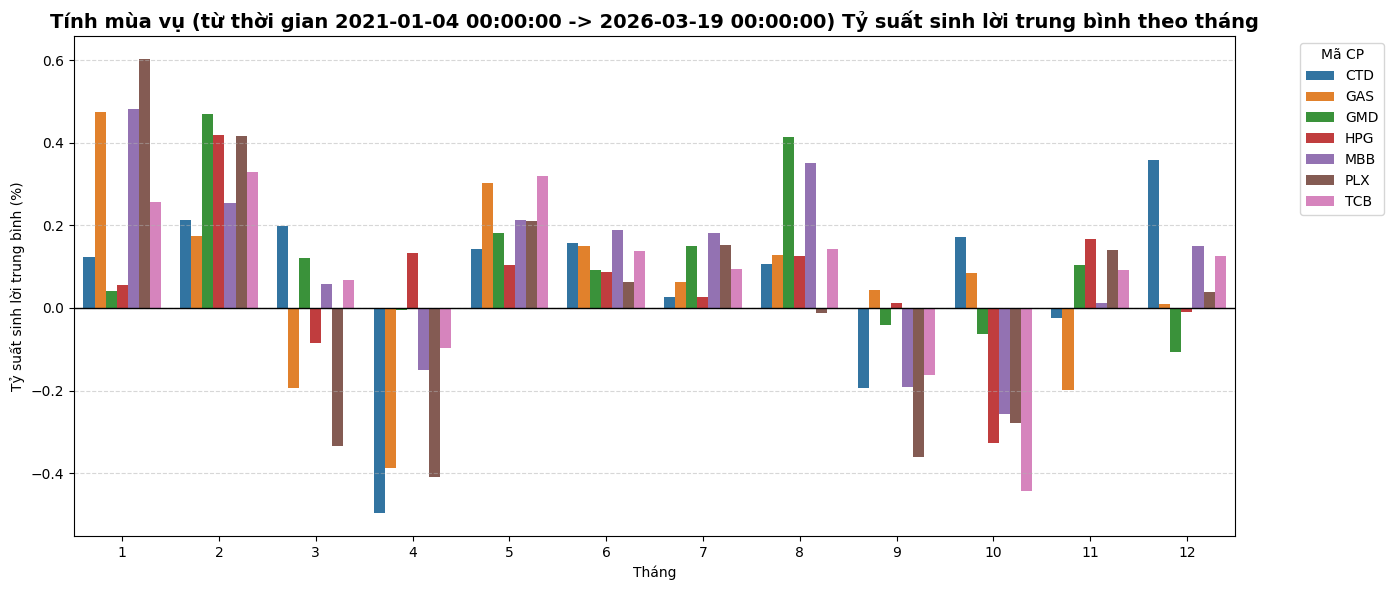

In [186]:
plt.figure(figsize=(14, 6))
sns.barplot(data=profitable, x="Month", y="Return_pct", hue="Ticker")
plt.title(f"Tính mùa vụ (từ thời gian {start} -> {all_start.Date.max()}) Tỷ suất sinh lời trung bình theo tháng", fontsize=14, fontweight="bold")
plt.ylabel("Tỷ suất sinh lời trung bình (%)")
plt.xlabel("Tháng")
plt.axhline(0, color="black", linewidth=1)
plt.legend(title="Mã CP", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

**Nhận Xét**
- Có thể thấy tỷ suất sinh lời cao nhất vào tháng 1-2. Do bắt đầu vào năm mới ngân hàng và quỹ sẽ giải ngân cho năm mới. Nhà đầu tư sẽ phấn khởi và mua vào
- Đến tháng 3-4 tỷ suất sinh lời bị âm. Do đây là mùa báo cáo tài chính quý 1, họp đại hội cổ đông cũng đã xong. Nhà đầu tư có xu hướng nghỉ dài. Lực cầu yếu
- Tháng 5 là mùa chia cổ tức của các doanh nghiệp lớn như HPG nên dòng tiền đẩy giá lên cao
- Tháng 6-7 sau khi chia cổ tức xong, dòng tiền chốt lời và rút ra. Thêm nữa tháng 7 là đang chờ đợi báo cáo tài chính quý 2, thị trường rơi vào trống thông tin, thanh khoản ít
- Tháng 8 tỷ suất sinh lời vọt lên cao vì báo cáo tài chính quý 2 bắt buộc phải có Kiểm toán độc lập tham gia. Doanh nghiệp nào làm ăn thật và có lãi thì dòng tiền lớn mới quay lại giải ngân để đánh sóng cuối năm
- Tháng 10 tỷ suất sinh lời âm nhiều nhất vì trong lịch sử hay xảy ra các tin tức vĩ mô bất lợi hoặc thanh lọc thị trường gây lên tâm lí hoảng loạn và kích hoạt các đợt bán tháo của nhà đầu tư 

![image.png](images/BCTC.png)

### Mối quan hệ giữa thị trường Phái sinh và thị trường Cơ sở
- VNINDEX: Nơi chúng ta mua bán cổ phiếu gọi là thị trường Cơ sở (T+2.5)
- VN30: Là điểm số đại diện cho 30 công ty vốn hóa lớn nhất, thanh khoản cao nhất trên thị trường cơ sở. Còn được gọi là cổ phiếu Trụ
- VN30F1M: Nơi nhà đầu tư không mua bán thật mà là nơi đặt cược tăng hay giảm vào việc chỉ số VN30 sẽ như thế nào trong tương lai (T+0). Đặc biệt hơn hợp đồng phái sinh bắt buộc phải đáo hạn vào thứ Năm tuần thứ 3 của tháng

**Vào lúc 14h45 ngày Đáo hạn, Giá Phái sinh BẮT BUỘC phải bằng chính xác Điểm số Cơ sở VN30**

- Hiểu đơn giản là thị trường Phái sinh sẽ liên tục đuổi theo VN30 mà VN30 thuộc thị trường cơ sở
- Điều này dễ xảy ra hiện tượng thao túng thị trường Phái sinh
    + Ví dụ: Cá mập họ mở nhiều lênh Long bên thị trường Phái sinh, sau đó họ sang bên thị trường Cơ sở đặt mua những mã cổ phiếu Trụ, kéo nó lên trần. Điều này khiến VN30 tăng điểm, họ sẽ đóng lệnh bên Long bên Phái sinh và chốt lãi
    + Ngược lại với lệnh Short, họ sẽ mang những mã cổ phiếu Trụ ra bán tháo (thường là sau 14h). Sẽ khiến VN30 sập xuống

=> Hiện tượng này gọi là "Sự trả điểm". Sau khi thực hiện xong (ngừng bơm tiền / ngừng xả hàng) thị trường sẽ lại quay về như lúc ban đầu

- Bản chất của lệnh Short đó là Long: Tức là đặt lệnh Short (tin thị trường xuống) thì sẽ bán hợp đồng  với người đặt lệnh Long (tin thị trường lên). Nếu thị trường xuống thật, muốn chốt lãi cần phải MUA hợp đồng từ một người nào đó đang muốn BÁN ra trên thị trường


In [187]:
market= ["VNINDEX", "VN30", "VN30F1M"]
df_stock= df_all[~df_all["Ticker"].isin(market)].copy()
df_market= df_all[df_all["Ticker"].isin(market)].copy()

In [188]:
table_market= df_market.pivot_table(index="Date", columns="Ticker", values="Close").dropna()
table_market

Ticker,VN30,VN30F1M,VNINDEX
Date,,,
2021-01-04,1091.87,1109.4,1120.47
2021-01-05,1104.30,1111.0,1132.55
2021-01-06,1113.72,1125.0,1143.21
2021-01-07,1130.59,1148.9,1156.49
2021-01-08,1147.86,1176.6,1167.69
...,...,...,...
2026-03-12,1859.80,1853.0,1709.61
2026-03-13,1853.60,1840.0,1696.24
2026-03-16,1852.99,1851.3,1693.21


- Basis = Giá Phái sinh (VN30F) - Điểm số VN30
    + Basis Dương: Thể hiện tâm lí lạc quan thị trường sẵn sàng trả giá cao. Tuy nhiên nếu Basis quá lớn (>10 điểm). Cá mập sẽ bán khống (Short) Phái sinh và mua Cơ sở để ăn chênh lệch
        - Ví dụ: Điểm Cơ sở (VN30) đang là 1200, do hưng phấn nên đua nhau cược tăng giá phái sinh bị đẩy lên 1220 -> Basis tăng 20 điểm. Cá mập sẽ bán (Short) Phái sinh ở mức 1220 điểm và bỏ tiền mua Cổ phiếu trong VN30 ở mức 1200
        * Trường hợp A: Thị trường sập về (1100): Cổ phiếu lỗ (100 điểm) nhưng lệnh Short phái sinh lãi (120 điểm) -> 120-100=20
        * Trường hợp B: Thị trường tăng lên (1300): Lệnh Short lỗ (80 điểm) nhưng Cổ phiếu lãi (100 điểm) -> 100-80=20


    + Basis Âm: Thể hiện tâm lí bi quan, sợ hãi thị trường sập. Nếu Basis quá âm (<-15 điểm) thường thị trường Cơ sở sẽ bị đạp mạnh để bắt kịp sự bi quan của Phái sinh

In [189]:
table_market["Basis"]= table_market["VN30F1M"]- table_market["VN30"]
table_market["T_1"]= table_market["VN30"].pct_change().shift(-1)*100
table_market["T_2"]= table_market["VN30"].pct_change(periods=2).shift(-2)*100
table_market

Ticker,VN30,VN30F1M,VNINDEX,Basis,T_1,T_2
Date,,,,,,
2021-01-04,1091.87,1109.4,1120.47,17.53,1.138414,2.001154
2021-01-05,1104.30,1111.0,1132.55,6.70,0.853029,2.380694
2021-01-06,1113.72,1125.0,1143.21,11.28,1.514743,3.065402
2021-01-07,1130.59,1148.9,1156.49,18.31,1.527521,2.902025
2021-01-08,1147.86,1176.6,1167.69,28.74,1.353824,1.844302
...,...,...,...,...,...,...
2026-03-12,1859.80,1853.0,1709.61,-6.80,-0.333369,-0.366168
2026-03-13,1853.60,1840.0,1696.24,-13.60,-0.032909,1.081679
2026-03-16,1852.99,1851.3,1693.21,-1.69,1.114955,0.855374


In [190]:
def category_Basis(Basis):
    if Basis< -10: return "1. Âm Nặng (< -10)"
    elif -10<= Basis< -5: return "2. Âm Nhẹ (-10 đến -5)"
    elif -5<= Basis<= 5: return "3. Bình Thường (-5 đến 5)"
    elif 5< Basis<= 10: return "4. Dương Nhẹ (5 đến 10)"
    else: return "5. Dương Nặng (> 10)"

table_market["Category_Basis"]= table_market["Basis"].apply(category_Basis)

In [191]:
# Nhóm các ngày có cùng trạng thái Basis để xem xác suất T+ tăng hay giảm 
check_basis= table_market.groupby("Category_Basis")[["T_1", "T_2"]].mean().reset_index()
check_basis

Ticker,Category_Basis,T_1,T_2
0,1. Âm Nặng (< -10),-0.397885,-0.264957
1,2. Âm Nhẹ (-10 đến -5),-0.152357,-0.186491
2,3. Bình Thường (-5 đến 5),-0.032538,0.092770
3,4. Dương Nhẹ (5 đến 10),0.232879,0.176510
4,5. Dương Nặng (> 10),51.702438,51.779534


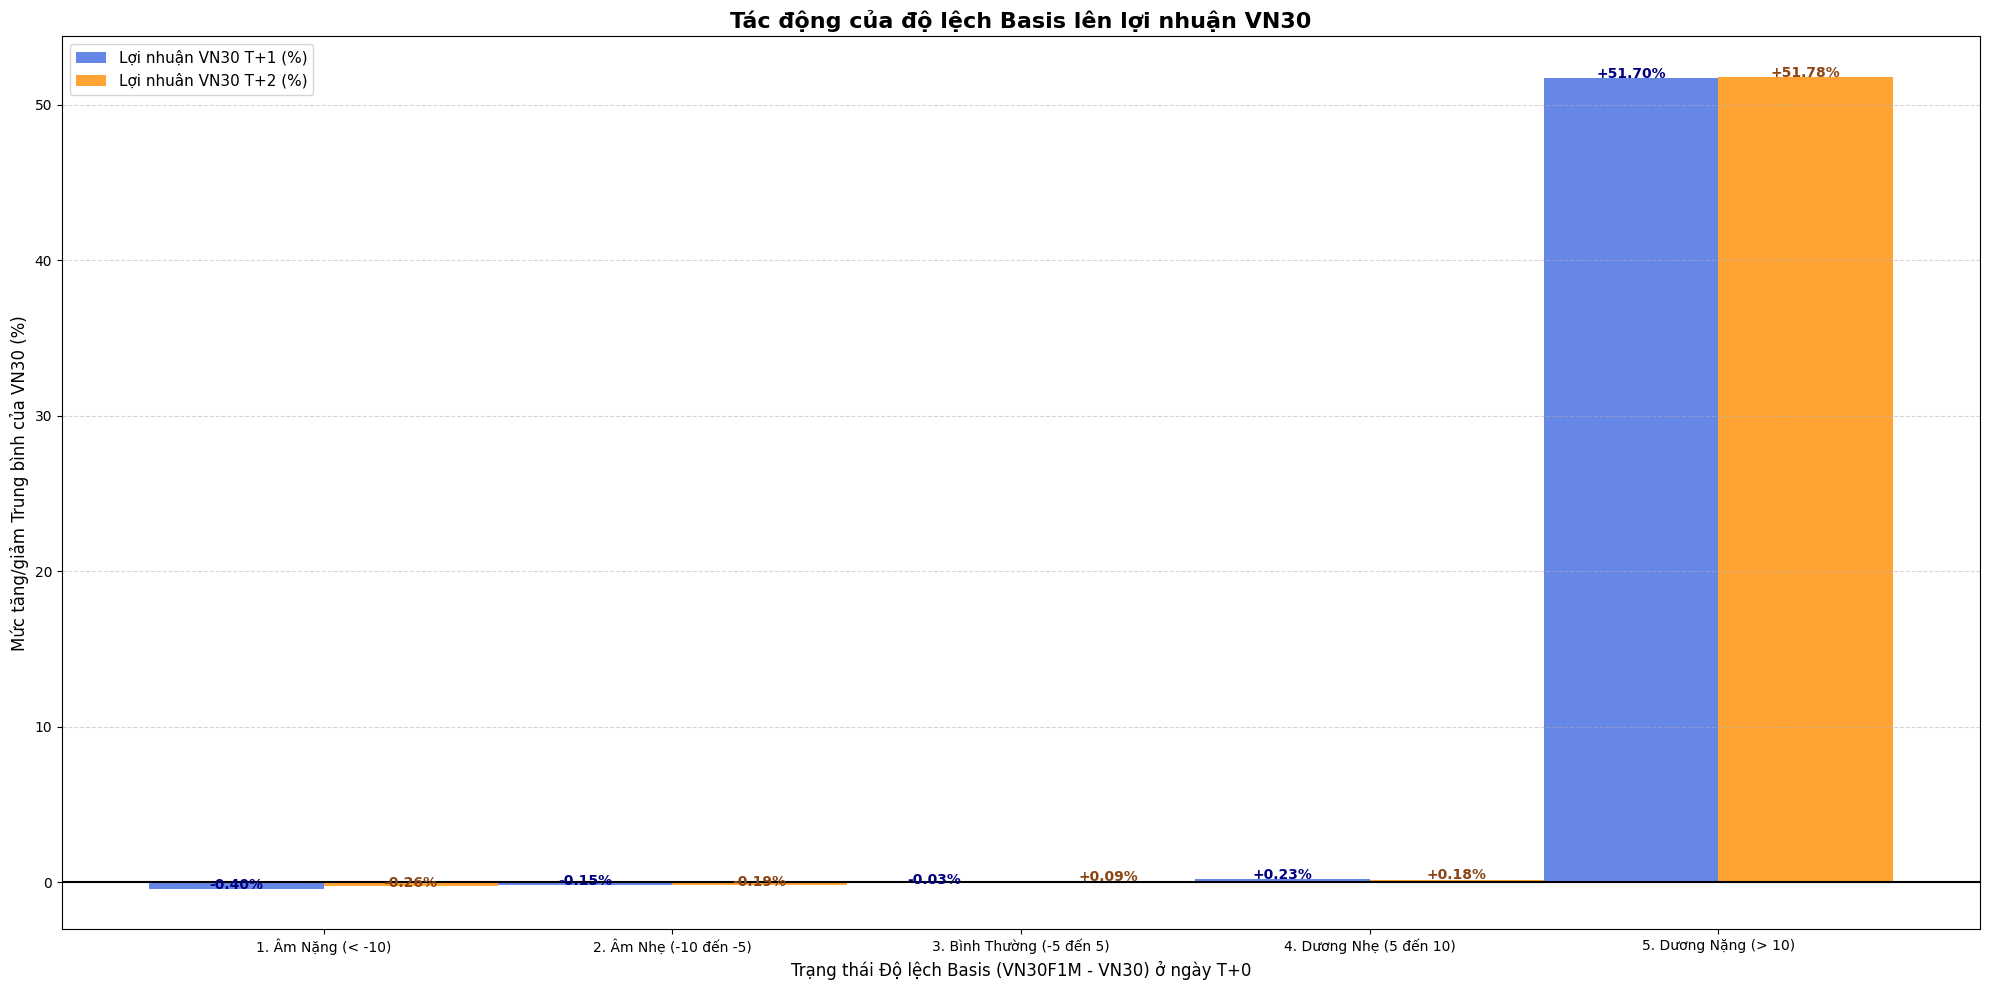

In [192]:
plt.figure(figsize=(20,10))
bar_width= 0.5
index= np.arange(len(check_basis))

plt.bar(index, check_basis["T_1"], bar_width, label="Lợi nhuận VN30 T+1 (%)", color="royalblue", alpha=0.8)
plt.bar(index+ bar_width,check_basis["T_2"], bar_width, label="Lợi nhuân VN30 T+2 (%)", color="darkorange", alpha=0.8)
plt.title("Tác động của độ lệch Basis lên lợi nhuận VN30", fontsize=16, fontweight= "bold");
plt.xticks(index+bar_width/2, [x for x in check_basis["Category_Basis"]]);
plt.axhline(0, color="black", linewidth=1.5);
plt.ylabel("Mức tăng/giảm Trung bình của VN30 (%)", fontsize=12)
plt.xlabel("Trạng thái Độ lệch Basis (VN30F1M - VN30) ở ngày T+0", fontsize=12);

for i, row in enumerate(check_basis.itertuples()):
    plt.text(i, row.T_1 + (0.015 if row.T_1 >= 0 else -0.04), 
             f"{row.T_1:+.2f}%", ha="center", fontsize=10, fontweight="bold", color="navy")
    plt.text(i + bar_width, row.T_2 + (0.015 if row.T_2 >= 0 else -0.04), 
             f"{row.T_2:+.2f}%", ha="center", fontsize=10, fontweight="bold", color="saddlebrown")

plt.legend(loc="upper left", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


**Nhận Xét**

### Biểu đồ Rủi ro và Lợi nhuận

In [193]:
# Tỷ suất sinh lời hàng ngày
risk_profit= df_stock.copy()
risk_profit["Daily_Return"]= risk_profit.groupby("Ticker")["Close"].pct_change()
risk_profit

,Date,Ticker,Open,High,Low,Close,Volume,Daily_Return
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,NaN
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,-0.007225
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,0.018923
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,0.001786
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.008200
...,...,...,...,...,...,...,...,...
29796,2026-03-13,VRE,25.60,26.00,25.25,25.25,3440100.0,-0.025097
29797,2026-03-16,VRE,25.25,25.90,25.10,25.90,4825600.0,0.025743
29798,2026-03-17,VRE,26.00,26.90,25.90,26.45,5159000.0,0.021236
29799,2026-03-18,VRE,26.50,26.95,26.10,26.10,3490200.0,-0.013233


In [194]:
count= risk_profit.groupby("Ticker")["Close"].count()
ticker_count= count[count>252].index
print(ticker_count)
risk_profit= risk_profit[risk_profit["Ticker"].isin(ticker_count)]
risk_profit

Index(['BID', 'BVH', 'CTD', 'CTG', 'FPT', 'GAS', 'GMD', 'HPG', 'MBB', 'MIG',
       'NT2', 'PC1', 'PLX', 'REE', 'STB', 'TCB', 'VCB', 'VHM', 'VIC', 'VNM',
       'VPB', 'VRE'],
      dtype='str', name='Ticker')


,Date,Ticker,Open,High,Low,Close,Volume,Daily_Return
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,NaN
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,-0.007225
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,0.018923
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,0.001786
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.008200
...,...,...,...,...,...,...,...,...
29796,2026-03-13,VRE,25.60,26.00,25.25,25.25,3440100.0,-0.025097
29797,2026-03-16,VRE,25.25,25.90,25.10,25.90,4825600.0,0.025743
29798,2026-03-17,VRE,26.00,26.90,25.90,26.45,5159000.0,0.021236
29799,2026-03-18,VRE,26.50,26.95,26.10,26.10,3490200.0,-0.013233


In [195]:
# Lợi nhuận = Trung bình ngày * 252 ngày
# Rủi ro (Độ lệch chuẩn) = Độ lệch chuẩn ngày * căn bậc 2 của 252
metrics= risk_profit.groupby("Ticker")["Daily_Return"].agg(
    Profit=lambda x: x.mean() * 252 * 100,
    Risk=lambda x: x.std() * np.sqrt(252) * 100
).dropna().reset_index()
metrics


,Ticker,Profit,Risk
0,BID,12.769757,32.518626
1,BVH,10.551516,33.199061
2,CTD,18.409893,43.607966
3,CTG,19.866547,32.880572
4,FPT,25.137118,28.575480
5,GAS,13.648055,32.974834
6,GMD,28.512811,35.668668
7,HPG,13.660814,34.046677
8,MBB,28.197890,31.527925
9,MIG,19.259048,39.934687


In [196]:
median_profit= metrics["Profit"].median()
median_risk= metrics["Risk"].median()

def get_color(row):
    if row["Profit"] >= median_profit and row["Risk"] <= median_risk: 
        return "skyblue"
    elif row["Profit"] >= median_profit and row["Risk"] > median_risk: 
        return "orange"   
    elif row["Profit"] < median_profit and row["Risk"] <= median_risk: 
        return "gray"   
    else: 
        return "tomato"
metrics["Color"]= metrics.apply(get_color, axis=1)
metrics

,Ticker,Profit,Risk,Color
0,BID,12.769757,32.518626,gray
1,BVH,10.551516,33.199061,gray
2,CTD,18.409893,43.607966,orange
3,CTG,19.866547,32.880572,skyblue
4,FPT,25.137118,28.575480,skyblue
5,GAS,13.648055,32.974834,gray
6,GMD,28.512811,35.668668,orange
7,HPG,13.660814,34.046677,tomato
8,MBB,28.197890,31.527925,skyblue
9,MIG,19.259048,39.934687,orange


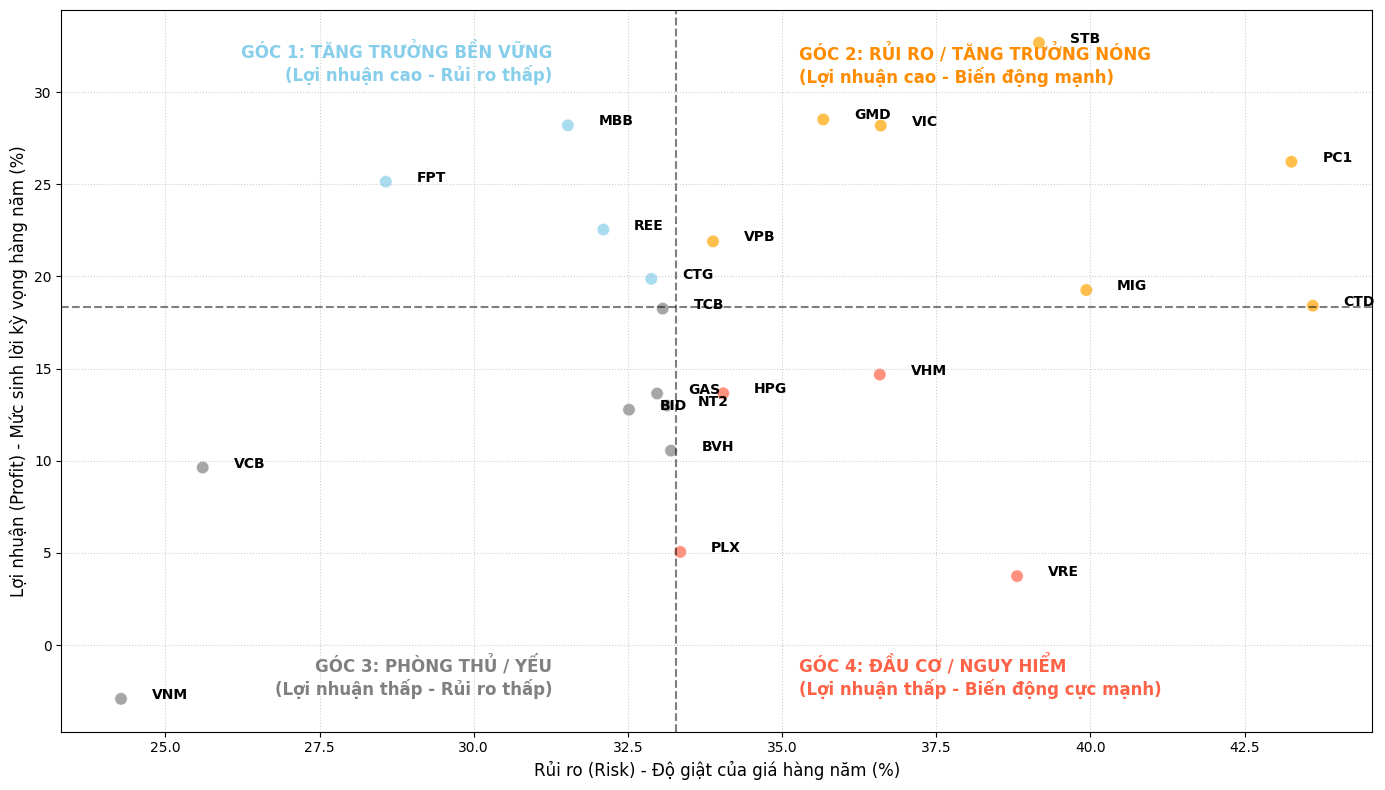

In [197]:
plt.figure(figsize=(14, 8))
plt.scatter(metrics["Risk"], metrics["Profit"], 
            c=metrics["Color"], s=80, alpha=0.7, edgecolors="white", linewidth=0.5)

plt.axvline(median_risk, color="black", linestyle="--", alpha=0.5)
plt.axhline(median_profit, color="black", linestyle="--", alpha=0.5)

plt.text(median_risk - 2, metrics["Profit"].max(), "GÓC 1: TĂNG TRƯỞNG BỀN VỮNG\n(Lợi nhuận cao - Rủi ro thấp)", 
         fontsize=12, color="skyblue", weight="bold", ha="right", va="top")
plt.text(median_risk + 2, metrics["Profit"].max(), "GÓC 2: RỦI RO / TĂNG TRƯỞNG NÓNG\n(Lợi nhuận cao - Biến động mạnh)", 
         fontsize=12, color="darkorange", weight="bold", ha="left", va="top")
plt.text(median_risk - 2, metrics["Profit"].min(), "GÓC 3: PHÒNG THỦ / YẾU\n(Lợi nhuận thấp - Rủi ro thấp)", 
         fontsize=12, color="gray", weight="bold", ha="right", va="bottom")
plt.text(median_risk + 2, metrics["Profit"].min(), "GÓC 4: ĐẦU CƠ / NGUY HIỂM\n(Lợi nhuận thấp - Biến động cực mạnh)", 
         fontsize=12, color="tomato", weight="bold", ha="left", va="bottom")


target_labels= risk_profit.Ticker.unique()
for idx, row in metrics.iterrows():
    ticker = row["Ticker"]
    if ticker in target_labels or row["Profit"] > 25 or row["Risk"] > 60:
        plt.text(row["Risk"] + 0.5, row["Profit"], ticker, 
                 fontsize=10, weight="bold", color="black")
        
plt.xlabel("Rủi ro (Risk) - Độ giật của giá hàng năm (%)", fontsize=12);
plt.ylabel("Lợi nhuận (Profit) - Mức sinh lời kỳ vọng hàng năm (%)", fontsize=12);
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

# Data Processing and Feature Processing

### Missing Date

In [198]:
def missing_date(df, date_col="Date", ticker_col="Ticker", output_file="Missing_Dates_Report.csv"):
    df_check= df.copy()
    df_check[date_col]= pd.to_datetime(df_check[date_col])

    calendar= pd.Series(sorted(df_check[date_col].unique()))
    results= []
    missing= []
    for ticker in df_check[ticker_col].unique():
        ticker_data= df_check[df_check[ticker_col] == ticker]
        ticker_dates= set(ticker_data[date_col])

        start_date= ticker_data[date_col].min()
        end_date= ticker_data[date_col].max()

        expected= set(calendar[(calendar>= start_date) & (calendar<= end_date)])
        missing_dates= expected - ticker_dates
        
        if missing_dates:
            results.append({
                "Ticker": ticker,
                "Missing_Days_Count": len(missing_dates)
            })
            for d in missing_dates:
                missing.append({
                    "Ticker": ticker,
                    "Missing_Date": d.strftime("%Y-%m-%d")
                })

    if missing:
        summary_df= pd.DataFrame(results).sort_values(by="Missing_Days_Count", ascending=False)
        details_df= pd.DataFrame(missing).sort_values(by=["Ticker", "Missing_Date"])
        details_df.to_csv(output_file, index=False)
        print(f"Đã lưu ra file:{output_file}")
    else:
        summary_df = pd.DataFrame(columns=["Ticker", "Missing_Days_Count"])
        details_df = pd.DataFrame(columns=["Ticker", "Missing_Date"])
        print("Không thiếu ngày nào")
    return summary_df, details_df

summary, details= missing_date(df_all, output_file="Missing_Dates_Report_ALL.csv")
if not summary.empty:
    display(summary)

Đã lưu ra file:Missing_Dates_Report_ALL.csv


,Ticker,Missing_Days_Count
0,MIG,6
2,VNINDEX,2
1,VN30F1M,1
3,VN30,1


**Nhận Xét**


### Xử lý giá trị bị thiếu
- Có 1 vấn đề ở đây, như đã biết dữ liệu bị mất hoàn toàn không phải dạng NaN, cho nên phải lấy bộ lịch chuẩn (Không bao gồm các ngày nghỉ) của cả thị trường để dùng. Và những mã chỉ số thị trường (VNINDEX, VN30, VN30F1M) bị mất vào những ngày giao dịch bình thường (2020-05-12) cho nên không thể dùng ffill và bfill được -> Sẽ chuyển sang nội suy tuyến tính 

In [199]:
df_stock[df_stock.Date=="2024-05-17"].head()

,Date,Ticker,Open,High,Low,Close,Volume
837,2024-05-17,BID,40.58,40.62,40.21,40.34,1518300.0
2133,2024-05-17,BVH,39.12,39.21,38.87,39.16,286900.0
3429,2024-05-17,CTD,63.52,65.74,63.43,65.56,2365500.0
4725,2024-05-17,CTG,22.87,22.91,22.57,22.70,5948500.0
6021,2024-05-17,FPT,99.10,99.53,97.85,98.44,2306400.0


In [200]:
# Có thể thấy không có VNINDEX
df_market[df_market.Date=="2024-05-17"]

,Date,Ticker,Open,High,Low,Close,Volume
25454,2024-05-17,VN30F1M,1306.80,1308.20,1301.90,1307.90,176193.0
31931,2024-05-17,VN30,1309.27,1312.95,1304.14,1310.15,269818400.0


In [201]:
df_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 32388 entries, 0 to 32387
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    32388 non-null  datetime64[us]
 1   Ticker  32388 non-null  str           
 2   Open    32388 non-null  float64       
 3   High    32388 non-null  float64       
 4   Low     32388 non-null  float64       
 5   Close   32388 non-null  float64       
 6   Volume  32388 non-null  float64       
dtypes: datetime64[us](1), float64(5), str(1)
memory usage: 1.8 MB


In [202]:
calendar_full= pd.Series(sorted(df_all.Date.unique()))
filter_date= calendar_full[calendar_full>="2021-01-04"].reset_index(drop=True)
filter_date

0      2021-01-04
1      2021-01-05
2      2021-01-06
3      2021-01-07
4      2021-01-08
          ...    
1291   2026-03-13
1292   2026-03-16
1293   2026-03-17
1294   2026-03-18
1295   2026-03-19
Length: 1296, dtype: datetime64[us]

In [203]:
df_filter= df_all[df_all.Date.isin(filter_date)].copy()
df_filter

,Date,Ticker,Open,High,Low,Close,Volume
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0
...,...,...,...,...,...,...,...
32383,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0
32384,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0
32385,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0
32386,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0


In [204]:
market_tickers= ["VNINDEX", "VN30", "VN30F1M"]
cleaned_data= []
price_cols= ["Open", "High", "Low", "Close"]

for ticker in df_filter["Ticker"].unique():
    ticker_df= df_filter[df_filter["Ticker"] == ticker].set_index("Date")
    start_date= ticker_df.index.min()
    end_date= ticker_df.index.max()
    ticker_calendar= filter_date[(filter_date >= start_date) & (filter_date <= end_date)]
    ticker_reindex= ticker_df.reindex(ticker_calendar)
    ticker_reindex["Ticker"]= ticker
    ticker_reindex[price_cols]= ticker_reindex[price_cols].ffill().bfill()
    if ticker in market_tickers:
        ticker_reindex["Volume"]= ticker_reindex["Volume"].ffill().bfill()
    else:
        ticker_reindex["Volume"]= ticker_reindex["Volume"].fillna(0)
    cleaned_data.append(ticker_reindex)

df_final= pd.concat(cleaned_data).reset_index()
df_final


,index,Ticker,Open,High,Low,Close,Volume
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0
...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0


In [205]:
df_final.rename(columns={"index": "Date"}, inplace=True)
df_final

,Date,Ticker,Open,High,Low,Close,Volume
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0
...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0


In [206]:
df_final[(df_final["Date"] == "2024-05-16") & (df_final["Ticker"].isin(market_tickers))]

,Date,Ticker,Open,High,Low,Close,Volume
25460,2024-05-16,VN30F1M,1295.10,1311.00,1294.20,1309.80,180049.0
30644,2024-05-16,VNINDEX,1264.51,1271.66,1261.19,1268.78,808757789.0
31939,2024-05-16,VN30,1300.06,1311.40,1296.77,1308.27,303274200.0


In [207]:
df_final[(df_final["Date"] == "2024-05-17") & (df_final["Ticker"].isin(market_tickers))]

,Date,Ticker,Open,High,Low,Close,Volume
25461,2024-05-17,VN30F1M,1306.80,1308.20,1301.90,1307.90,176193.0
30645,2024-05-17,VNINDEX,1264.51,1271.66,1261.19,1268.78,808757789.0
31940,2024-05-17,VN30,1309.27,1312.95,1304.14,1310.15,269818400.0


In [208]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 32398 entries, 0 to 32397
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    32398 non-null  datetime64[us]
 1   Ticker  32398 non-null  str           
 2   Open    32398 non-null  float64       
 3   High    32398 non-null  float64       
 4   Low     32398 non-null  float64       
 5   Close   32398 non-null  float64       
 6   Volume  32398 non-null  float64       
dtypes: datetime64[us](1), float64(5), str(1)
memory usage: 1.8 MB


## Tạo bộ lọc dòng tiền


### Đột biến Khối lượng (Vol_Spike): Phát hiện dòng tiền lớn gấp n lần trung bình

- Trên thị trường không thể ước lượng dòng tiền bằng cố đinh như gấp 2, gấp 3 là lớn. Bởi vì các mã cổ phiếu có giá trị và khối lượng khác nhau có thể gấp 2 ở cổ phiếu này là nhiều nhưng ở cổ phiếu khác là ít. Do đó ta sẽ dùng công thức Z_score để đưa về 1 hệ quy chiếu
- Z_Score còn có tác dụng co giãn theo thị trường. Nếu dùng tỷ lệ cố định, một mức thanh khoản đột biến trong Downtrend có thể lại chỉ là mức bình thường trong Uptrend.
- Z-Score sử dụng đường trượt 20 ngày ($SMA$ và $SD$ của 20 phiên gần nhất), nên nó liên tục tự động cập nhật và thích nghi với bối cảnh hiện tại của thị trường. Nó giúp lọc nhiễu cực tốt mà không cần phải tinh chỉnh lại các tham số thủ công

$$Vol\_Zscore = \frac{Volume_{today} - SMA(Volume, 20)}{Vol\_SD20}$$


In [209]:
df_features= df_final.copy()

In [210]:
df_features["Vol_MA20"]= df_features.groupby("Ticker")["Volume"].transform(lambda x: x.rolling(window=20, min_periods=1).mean())
df_features["Vol_SD20"]= df_features.groupby("Ticker")["Volume"].transform(lambda x: x.rolling(window=20, min_periods=1).std())
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_SD20
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06,NaN
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06,1.144806e+05
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06,9.271567e+05
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06,8.882974e+05
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06,7.842340e+05
...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,1.404792e+08
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,1.415581e+08
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,1.390225e+08
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,1.429914e+08


In [211]:
df_features["Vol_Zscore"]= (df_features["Volume"] - df_features["Vol_MA20"]) / df_features["Vol_SD20"].replace(0, np.nan)
df_features["Vol_Zscore"]= df_features["Vol_Zscore"].fillna(0)
df_features["Vol_Zscore"]= df_features["Vol_Zscore"].round(2)
df_features.drop(columns=["Vol_MA20","Vol_SD20"], inplace=True)
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35
...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09


### OBV (On-Balance Volume): Tìm kiếm sự phân kỳ (giá đi ngang nhưng tiền vẫn âm thầm bơm vào)

$$OBV_t = 
\begin{cases} 
OBV_{t-1} + Volume_t & \text{nếu } Close_t > Close_{t-1} \\
OBV_{t-1} - Volume_t & \text{nếu } Close_t < Close_{t-1} \\
OBV_{t-1} & \text{nếu } Close_t = Close_{t-1} 
\end{cases}$$

- Dùng OBV_Zscore là bởi vì ở mã này gấp 2, gấp 3 là nhiều nhưng ở mã khác đó là chuyện bình thường

In [212]:
df_features["Close_Diff"]= df_features.groupby("Ticker")["Close"].diff()
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,Close_Diff
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00,NaN
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71,-0.20
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15,0.52
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78,0.05
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35,-0.23
...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-30.14
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-6.20
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-0.61
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,20.66


In [213]:
conditional= [
    df_features["Close_Diff"]>0,
    df_features["Close_Diff"]<0
]
choice= [
    df_features["Volume"],
    -df_features["Volume"]
]

df_features["Daily_OBV"]= np.select(conditional,choice, default=0)
df_features


,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,Close_Diff,Daily_OBV
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00,NaN,0.0
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71,-0.20,-2155700.0
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15,0.52,3674500.0
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78,0.05,1678500.0
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35,-0.23,-2034900.0
...,...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-30.14,-380808184.0
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-6.20,-329393500.0
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-0.61,-279631333.0
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,20.66,262441729.0


In [ ]:
df_features["OBV"]= df_features.groupby("Ticker")['Daily_OBV'].cumsum() # Cộng dồn
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,Close_Diff,Daily_OBV,OBV
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00,NaN,0.0,0.000000e+00
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71,-0.20,-2155700.0,-2.155700e+06
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15,0.52,3674500.0,1.518800e+06
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78,0.05,1678500.0,3.197300e+06
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35,-0.23,-2034900.0,1.162400e+06
...,...,...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-30.14,-380808184.0,3.022319e+10
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-6.20,-329393500.0,2.989380e+10
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-0.61,-279631333.0,2.961417e+10
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,20.66,262441729.0,2.987661e+10


In [215]:
df_features["OBV_MA20"]= df_features.groupby("Ticker")["OBV"].transform(lambda x: x.rolling(window=20, min_periods=1).mean())
df_features["OBV_STD20"]= df_features.groupby("Ticker")["OBV"].transform(lambda x: x.rolling(window=20, min_periods=1).std())
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,Close_Diff,Daily_OBV,OBV,OBV_MA20,OBV_STD20
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00,NaN,0.0,0.000000e+00,0.000000e+00,NaN
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71,-0.20,-2155700.0,-2.155700e+06,-1.077850e+06,1.524310e+06
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15,0.52,3674500.0,1.518800e+06,-2.123000e+05,1.846427e+06
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78,0.05,1678500.0,3.197300e+06,6.401000e+05,2.275786e+06
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35,-0.23,-2034900.0,1.162400e+06,7.445600e+05,1.984682e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-30.14,-380808184.0,3.022319e+10,3.100556e+10,8.036150e+08
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-6.20,-329393500.0,2.989380e+10,3.099023e+10,8.224885e+08
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-0.61,-279631333.0,2.961417e+10,3.094900e+10,8.708300e+08
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,20.66,262441729.0,2.987661e+10,3.090293e+10,9.030168e+08


In [216]:
df_features["OBV_Zscore"]= (df_features["OBV"] - df_features["OBV_MA20"]) / df_features["OBV_STD20"].replace(0, np.nan)
df_features["OBV_Zscore"]= df_features["OBV_Zscore"].fillna(0).round(2)
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,Close_Diff,Daily_OBV,OBV,OBV_MA20,OBV_STD20,OBV_Zscore
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00,NaN,0.0,0.000000e+00,0.000000e+00,NaN,0.00
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71,-0.20,-2155700.0,-2.155700e+06,-1.077850e+06,1.524310e+06,-0.71
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15,0.52,3674500.0,1.518800e+06,-2.123000e+05,1.846427e+06,0.94
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78,0.05,1678500.0,3.197300e+06,6.401000e+05,2.275786e+06,1.12
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35,-0.23,-2034900.0,1.162400e+06,7.445600e+05,1.984682e+06,0.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-30.14,-380808184.0,3.022319e+10,3.100556e+10,8.036150e+08,-0.97
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-6.20,-329393500.0,2.989380e+10,3.099023e+10,8.224885e+08,-1.33
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-0.61,-279631333.0,2.961417e+10,3.094900e+10,8.708300e+08,-1.53
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,20.66,262441729.0,2.987661e+10,3.090293e+10,9.030168e+08,-1.14


In [217]:
df_features.drop(columns=["Close_Diff", "Daily_OBV", "OBV_MA20", "OBV_STD20", "OBV"], inplace=True)
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,OBV_Zscore
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00,0.00
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71,-0.71
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15,0.94
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78,1.12
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35,0.21
...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-0.97
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-1.33
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-1.53
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,-1.14


- Z_Score: Phân Phối Chuẩn:
    + Vùng $\pm 1\sigma$ (Z-Score từ -1.0 đến 1.0) - Bao phủ 68.2% dữ liệu:
        * Ý nghĩa: Khoảng 68.2% thời gian, thanh khoản hàng ngày của cổ phiếu sẽ chỉ dao động nhẹ nhàng trong ranh giới này
        * Bản chất: Đây là trạng thái "bình yên". Cung cầu tự nhiên của nhỏ lẻ gặp nhau. Trong quá trình làm sạch dữ liệu (EDA), mọi dao động ở vùng này được xem là nhiễu ngẫu nhiên (noise) và không mang nhiều ý nghĩa dự báo xu hướng
    + Vùng $\pm 2\sigma$ (Z-Score từ -2.0 đến 2.0) - Bao phủ 95.4% dữ liệu:
        * Ý nghĩa: Thanh khoản gần như bị khóa chặt trong vùng này (chiếm hơn 95% tổng số phiên)
        * Bản chất: Bao trọn các biến động thông thường của thị trường. Dù là một cổ phiếu giao dịch êm đềm như MBB hay có tính đầu cơ mạnh hơn như VIC, khi ép vào phân phối chuẩn, 95.4% các phiên giao dịch của chúng đều nằm gọn ở đây
    + Vùng $\pm 3\sigma$ (Z-Score từ -3.0 đến 3.0) - Bao phủ 99.7% dữ liệu:
        * Ý nghĩa: Giới hạn cực đại. Gần như mọi phiên giao dịch trong lịch sử cổ phiếu đều rơi vào trong khu vực này

? Lí do tại sao hay lấy Z > 2, Z < -2: Bởi vì đa số giao dịch đã nằm trong 95.4% dữ liệu, chỉ còn 4.6% bên ngoài chia đều 2 bên là 2.3. Lúc này đã có dấu hiệu của tổ chức tham gia vào với khối lượng khổng lồ và số tiền lớn

### CMF (Chaikin Money Flow): Đo lường áp lực Mua/Bán chủ động trong phiên
Bước 1: Tính Hệ số Dòng tiền (Money Flow Multiplier) Đo lường xem giá đóng cửa nằm ở đâu so với biên độ của cây nến.$$MF\_Multiplier = \frac{(Close - Low) - (High - Close)}{High - Low}$$
- Nếu đóng cửa ở mức cao nhất phiên ($Close = High$): Hệ số là $+1$ (Lực mua tuyệt đối)
- Nếu đóng cửa ở mức thấp nhất phiên ($Close = Low$): Hệ số là $-1$ (Lực bán tuyệt đối).
- Nếu đóng cửa ở giữa phiên: Hệ số là $0$ (Giằng co cân bằng).

Bước 2: Tính Khối lượng Dòng tiền (Money Flow Volume)$$MF\_Volume = MF\_Multiplier \times Volume$$
Bước 3: Tính CMF (Thường dùng chu kỳ 20 phiên)$$CMF = \frac{\sum_{i=1}^{20} MF\_Volume_i}{\sum_{i=1}^{20} Volume_i}$$

- CMF > 0.20: Dòng tiền mua chủ động rất mạnh và liên tục. Tay to đang gom hàng quyết liệt, sẵn sàng đánh vượt đỉnh (Breakout).

- CMF < -0.20: Áp lực xả hàng tàng hình. Dù giá có thể chưa giảm sâu, nhưng cấu trúc nến liên tục bị chốt ngược. AI sẽ nhận diện đây là vùng rủi ro và kích hoạt lệnh Bán/Short.

- CMF quanh mức 0: Trạng thái lình xình, không có bên nào kiểm soát thế trận.

In [218]:
high_low_diff= df_features["High"] - df_features["Low"]
high_low_diff

0         0.40
1         0.25
2         1.75
3         0.81
4         0.64
         ...  
32393    28.44
32394    34.93
32395    22.10
32396    33.31
32397    40.46
Length: 32398, dtype: float64

In [219]:
df_features["MF_Multiplier"]= np.where(
    high_low_diff == 0, 
    0, 
    ((df_features["Close"] - df_features["Low"]) - (df_features["High"] - df_features["Close"])) / high_low_diff
)
df_features


,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,OBV_Zscore,MF_Multiplier
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00,0.00,0.400000
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71,-0.71,0.120000
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15,0.94,-0.188571
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78,1.12,-0.432099
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35,0.21,-0.468750
...,...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-0.97,-0.395218
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-1.33,-0.192098
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-1.53,0.021719
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,-1.14,-0.698589


In [220]:
df_features["MF_Volume"]= df_features["MF_Multiplier"] * df_features["Volume"]
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,OBV_Zscore,MF_Multiplier,MF_Volume
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00,0.00,0.400000,7.975200e+05
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71,-0.71,0.120000,2.586840e+05
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15,0.94,-0.188571,-6.929057e+05
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78,1.12,-0.432099,-7.252778e+05
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35,0.21,-0.468750,-9.538594e+05
...,...,...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-0.97,-0.395218,-1.505022e+08
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-1.33,-0.192098,-6.327599e+07
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-1.53,0.021719,6.073441e+06
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,-1.14,-0.698589,-1.833389e+08


In [221]:
sum_mfv= df_features.groupby("Ticker")["MF_Volume"].transform(lambda x: x.rolling(window=20, min_periods=1).sum())
sum_vol= df_features.groupby("Ticker")["Volume"].transform(lambda x: x.rolling(window=20, min_periods=1).sum())

In [222]:
df_features["CMF"]= np.where(
    sum_vol == 0,
    0,
    sum_mfv / sum_vol
)
df_features["CMF"]= df_features["CMF"].round(2)

In [223]:
df_features.drop(columns=['MF_Multiplier', 'MF_Volume'], inplace=True)
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,OBV_Zscore,CMF
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00,0.00,0.40
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71,-0.71,0.25
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15,0.94,0.05
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78,1.12,-0.04
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35,0.21,-0.11
...,...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-0.97,-0.23
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-1.33,-0.19
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-1.53,-0.17
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,-1.14,-0.19


### VWAP: Đo lường giá vốn thực tế

1. Mức giá đại diện trong phiên (Typical Price):Triệt tiêu sự nhiễu loạn của việc kéo/đạp ATC bằng cách lấy trung bình sức mạnh toàn phiên.$$Typical\_Price = \frac{High + Low + Close}{3}$$2. Trọng số hóa dòng tiền (Price Volume):$$Price\_Volume = Typical\_Price \times Volume$$3. Giá vốn trung bình 20 ngày (Rolling VWAP):Tổng lượng tiền thực tế đã giao dịch chia cho tổng số lượng cổ phiếu đã sang tay.$$VWAP\_20D = \frac{\sum_{i=1}^{20} Price\_Volume_i}{\sum_{i=1}^{20} Volume_i}$$4. Đặc trưng khoảng cách (Distance to VWAP) - Biến số dành cho AI:Đo lường độ lệch giữa bề mặt bảng điện (Close) và bản chất dòng tiền (VWAP).$$Dist\_VWAP\_20D = \frac{Close}{VWAP\_20D} - 1$$

In [224]:
df_features["Typical_Price"]= (df_features["High"] + df_features["Low"] + df_features["Close"]) / 3
df_features["Price_x_Volume"]= df_features["Typical_Price"] * df_features["Volume"]
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,OBV_Zscore,CMF,Typical_Price,Price_x_Volume
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00,0.00,0.40,27.626667,5.508205e+07
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71,-0.71,0.25,27.470000,5.921708e+07
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15,0.94,0.05,28.110000,1.032902e+08
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78,1.12,-0.04,28.166667,4.727775e+07
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35,0.21,-0.11,27.920000,5.681441e+07
...,...,...,...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-0.97,-0.23,1863.546667,7.096538e+11
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-1.33,-0.19,1855.836667,6.113005e+11
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-1.53,-0.17,1852.830000,5.181093e+11
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,-1.14,-0.19,1881.406667,4.937596e+11


In [225]:
sum_pv_20d= df_features.groupby("Ticker")["Price_x_Volume"].transform(lambda x: x.rolling(20, min_periods=1).sum())
sum_vol_20d= df_features.groupby("Ticker")["Volume"].transform(lambda x: x.rolling(20, min_periods=1).sum())

df_features["VWAP_20D"]= sum_pv_20d / (sum_vol_20d + 1e-9)
df_features["Dist_VWAP_20D"]= (df_features["Close"] / df_features["VWAP_20D"]) - 1
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,OBV_Zscore,CMF,Typical_Price,Price_x_Volume,VWAP_20D,Dist_VWAP_20D
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00,0.00,0.40,27.626667,5.508205e+07,27.626667,0.001931
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71,-0.71,0.25,27.470000,5.921708e+07,27.545277,-0.002370
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15,0.94,0.05,28.110000,1.032902e+08,27.810496,0.006814
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78,1.12,-0.04,28.166667,4.727775e+07,27.873409,0.006335
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35,0.21,-0.11,27.920000,5.681441e+07,27.881627,-0.002210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-0.97,-0.23,1863.546667,7.096538e+11,1957.685323,-0.050001
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-1.33,-0.19,1855.836667,6.113005e+11,1954.018289,-0.051391
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-1.53,-0.17,1852.830000,5.181093e+11,1950.750962,-0.050115
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,-1.14,-0.19,1881.406667,4.937596e+11,1948.498393,-0.038413


In [226]:
df_features.drop(columns=["Typical_Price", "Price_x_Volume", "VWAP_20D"], inplace=True)

### VSA Signals: Nhận diện nến Gom hàng, Xả hàng, Cao trào bán (Selling Climax), Bẫy bứt phá (Bull-trap)

<table style="width: 100%;">
  <tr align="center">
    <td><img src="images/fakebreak.jpg" style="width: 100%;"></td>
    <td><img src="images/sell3.jpg" style="width: 100%;"></td>
    <td><img src="images/trap3.jpg" style="width: 100%;"></td>
  </tr>
  <tr align="center">
    <td><i>Fakebreak</i></td>
    <td><i>Sell Signal</i></td>
    <td><i>Bull Trap</i></td>
  </tr>
</table>

$$Spread = High - Low \quad \text{(Biên độ toàn nến)}$$

$$Body = |Close - Open| \quad \text{(Độ dài Thân nến)}$$

$$Upper\_Wick = High - \max(Open, Close) \quad \text{(Độ dài Râu trên)}$$

$$Lower\_Wick = \min(Open, Close) - Low \quad \text{(Độ dài Râu dưới)}$$

$$Close\_Pos = \frac{Close - Low}{Spread} \quad \text{(Vị trí đóng cửa, thang điểm 0 - 1)}$$

$$Prev\_Close = Close_{t-1} \quad \text{(Giá đóng cửa phiên trước)}$$

$$Spread\_MA20 = \frac{1}{20} \sum_{i=1}^{20} Spread_{t-i} \quad \text{(Trung bình Biên độ 20 phiên)}$$

$$Body\_Ratio = \frac{Body}{Spread} \quad \text{(Tỷ lệ Thân nến trên Biên độ)}$$

$$Upper\_Wick\_Ratio = \frac{Upper\_Wick}{Spread} \quad \text{(Tỷ lệ Râu trên trên Biên độ)}$$

$$Lower\_Wick\_Ratio = \frac{Lower\_Wick}{Spread} \quad \text{(Tỷ lệ Râu dưới trên Biên độ)}$$

$$Spread\_Ratio = \frac{Spread}{Spread\_MA20} \quad \text{(Tỷ lệ Biên độ so với trung bình 20 phiên)}$$

$$VSA\_Selling\_Climax = Lower\_Wick\_Ratio \times \max(0, Vol\_Zscore) \times \max(0, -Dist\_VWAP\_20D) \times 100 \quad \text{(Cường độ Cao trào bán)}$$

$$VSA\_Bull\_Trap = Upper\_Wick\_Ratio \times \max(0, Vol\_Zscore) \times \max(0, Dist\_VWAP\_20D) \times 100 \quad \text{(Cường độ Bẫy tăng giá)}$$

$$VSA\_Distribution = \text{If}(Open > Close, Body\_Ratio, 0) \times \max(0, Vol\_Zscore) \quad \text{(Cường độ Phân phối)}$$

$$VSA\_No\_Supply = \max(0, 1 - Spread\_Ratio) \times \max(0, -Vol\_Zscore) \times \text{If}(Close < Prev\_Close, 1, 0) \quad \text{(Cường độ Cạn cung)}$$


In [227]:
df_features["Spread"]= df_features["High"] - df_features["Low"]
df_features["Body"]= abs(df_features["Close"] - df_features["Open"]) 
df_features["Upper_Wick"]= df_features["High"] - df_features[["Open", "Close"]].max(axis=1)
df_features["Lower_Wick"]= df_features[["Open", "Close"]].min(axis=1) - df_features["Low"]
df_features["Prev_Close"]= df_features.groupby("Ticker")["Close"].shift(1) 
df_features["Spread_MA20"]= df_features.groupby("Ticker")["Spread"].transform(lambda x: x.rolling(20, min_periods=1).mean())
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,OBV_Zscore,CMF,Dist_VWAP_20D,Spread,Body,Upper_Wick,Lower_Wick,Prev_Close,Spread_MA20
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00,0.00,0.40,0.001931,0.40,0.28,0.12,0.00,NaN,0.4000
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71,-0.71,0.25,-0.002370,0.25,0.00,0.11,0.14,27.68,0.3250
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15,0.94,0.05,0.006814,1.75,0.29,1.04,0.42,27.48,0.8000
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78,1.12,-0.04,0.006335,0.81,0.05,0.58,0.18,28.00,0.8025
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35,0.21,-0.11,-0.002210,0.64,0.47,0.00,0.17,28.05,0.7700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-0.97,-0.23,-0.050001,28.44,3.12,16.72,8.60,1889.94,39.9875
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-1.33,-0.19,-0.051391,34.93,6.09,20.82,8.02,1859.80,40.4545
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-1.53,-0.17,-0.050115,22.10,1.81,9.00,11.29,1853.60,40.6760
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,-1.14,-0.19,-0.038413,33.31,4.50,28.29,0.52,1852.99,40.6315


In [228]:
safe_spread= df_features["Spread"].replace(0, np.nan)
df_features["Close_Pos"]= np.where(
    df_features["Spread"] == 0,
    0.5,
    (df_features["Close"] - df_features["Low"]) / safe_spread)

df_features["Body_Ratio"]= (df_features["Body"] / safe_spread).fillna(0)
df_features["Upper_Wick_Ratio"]= (df_features["Upper_Wick"] / safe_spread).fillna(0)
df_features["Lower_Wick_Ratio"]= (df_features["Lower_Wick"] / safe_spread).fillna(0)
df_features["Spread_Ratio"]= (df_features["Spread"] / df_features["Spread_MA20"].replace(0, np.nan)).fillna(1)
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,OBV_Zscore,CMF,...,Body,Upper_Wick,Lower_Wick,Prev_Close,Spread_MA20,Close_Pos,Body_Ratio,Upper_Wick_Ratio,Lower_Wick_Ratio,Spread_Ratio
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00,0.00,0.40,...,0.28,0.12,0.00,NaN,0.4000,0.700000,0.700000,0.300000,0.000000,1.000000
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71,-0.71,0.25,...,0.00,0.11,0.14,27.68,0.3250,0.560000,0.000000,0.440000,0.560000,0.769231
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15,0.94,0.05,...,0.29,1.04,0.42,27.48,0.8000,0.405714,0.165714,0.594286,0.240000,2.187500
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78,1.12,-0.04,...,0.05,0.58,0.18,28.00,0.8025,0.283951,0.061728,0.716049,0.222222,1.009346
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35,0.21,-0.11,...,0.47,0.00,0.17,28.05,0.7700,0.265625,0.734375,0.000000,0.265625,0.831169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-0.97,-0.23,...,3.12,16.72,8.60,1889.94,39.9875,0.302391,0.109705,0.587904,0.302391,0.711222
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-1.33,-0.19,...,6.09,20.82,8.02,1859.80,40.4545,0.403951,0.174349,0.596049,0.229602,0.863439
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-1.53,-0.17,...,1.81,9.00,11.29,1853.60,40.6760,0.510860,0.081900,0.407240,0.510860,0.543318
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,-1.14,-0.19,...,4.50,28.29,0.52,1852.99,40.6315,0.150705,0.135095,0.849295,0.015611,0.819807


- Intensity = Râu nến * Volume * Độ sâu VWAP

In [229]:
# 1. CƯỜNG ĐỘ CAO TRÀO BÁN (Selling Climax)
deep_discount= np.maximum(0, -df_features["Dist_VWAP_20D"])
high_vol= np.maximum(0, df_features["Vol_Zscore"])

df_features["VSA_Selling_Climax_Intensity"] = (df_features["Lower_Wick_Ratio"] * high_vol * deep_discount * 100).round(4)

# 2. CƯỜNG ĐỘ BẪY TĂNG GIÁ (Bull Trap)
over_extended= np.maximum(0, df_features["Dist_VWAP_20D"])
df_features["VSA_Bull_Trap_Intensity"]= (df_features["Upper_Wick_Ratio"] * high_vol * over_extended * 100).round(4)

# 3. CƯỜNG ĐỘ PHÂN PHỐI (Distribution)
red_candle_intensity= np.where(df_features["Open"] > df_features["Close"], df_features["Body_Ratio"], 0)
df_features["VSA_Distribution_Intensity"]= (red_candle_intensity * high_vol).round(4)

# 4. CƯỜNG ĐỘ CẠN CUNG (No Supply)
dry_vol= np.maximum(0, -df_features["Vol_Zscore"]) 
narrow_spread= np.maximum(0, 1 - df_features["Spread_Ratio"])
down_close= np.where(df_features["Close"] < df_features["Prev_Close"], 1, 0)
df_features["VSA_No_Supply_Intensity"] = (narrow_spread * dry_vol * down_close).round(4)
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,OBV_Zscore,CMF,...,Spread_MA20,Close_Pos,Body_Ratio,Upper_Wick_Ratio,Lower_Wick_Ratio,Spread_Ratio,VSA_Selling_Climax_Intensity,VSA_Bull_Trap_Intensity,VSA_Distribution_Intensity,VSA_No_Supply_Intensity
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00,0.00,0.40,...,0.4000,0.700000,0.700000,0.300000,0.000000,1.000000,0.0000,0.0000,0.0,-0.0000
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71,-0.71,0.25,...,0.3250,0.560000,0.000000,0.440000,0.560000,0.769231,0.0942,0.0000,0.0,0.0000
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15,0.94,0.05,...,0.8000,0.405714,0.165714,0.594286,0.240000,2.187500,0.0000,0.4657,0.0,0.0000
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78,1.12,-0.04,...,0.8025,0.283951,0.061728,0.716049,0.222222,1.009346,0.0000,0.0000,0.0,0.0000
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35,0.21,-0.11,...,0.7700,0.265625,0.734375,0.000000,0.265625,0.831169,0.0000,0.0000,0.0,0.0591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-0.97,-0.23,...,39.9875,0.302391,0.109705,0.587904,0.302391,0.711222,0.0000,0.0000,0.0,0.0982
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-1.33,-0.19,...,40.4545,0.403951,0.174349,0.596049,0.229602,0.863439,0.0000,0.0000,0.0,0.0888
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-1.53,-0.17,...,40.6760,0.510860,0.081900,0.407240,0.510860,0.543318,0.0000,0.0000,0.0,0.4704
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,-1.14,-0.19,...,40.6315,0.150705,0.135095,0.849295,0.015611,0.819807,0.0000,0.0000,0.0,0.0000


In [230]:
df_features.drop(columns=["Spread", "Body", "Upper_Wick", "Lower_Wick", "Spread_MA20", "Prev_Close"], inplace=True)
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,OBV_Zscore,CMF,Dist_VWAP_20D,Close_Pos,Body_Ratio,Upper_Wick_Ratio,Lower_Wick_Ratio,Spread_Ratio,VSA_Selling_Climax_Intensity,VSA_Bull_Trap_Intensity,VSA_Distribution_Intensity,VSA_No_Supply_Intensity
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00,0.00,0.40,0.001931,0.700000,0.700000,0.300000,0.000000,1.000000,0.0000,0.0000,0.0,-0.0000
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71,-0.71,0.25,-0.002370,0.560000,0.000000,0.440000,0.560000,0.769231,0.0942,0.0000,0.0,0.0000
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15,0.94,0.05,0.006814,0.405714,0.165714,0.594286,0.240000,2.187500,0.0000,0.4657,0.0,0.0000
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78,1.12,-0.04,0.006335,0.283951,0.061728,0.716049,0.222222,1.009346,0.0000,0.0000,0.0,0.0000
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35,0.21,-0.11,-0.002210,0.265625,0.734375,0.000000,0.265625,0.831169,0.0000,0.0000,0.0,0.0591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-0.97,-0.23,-0.050001,0.302391,0.109705,0.587904,0.302391,0.711222,0.0000,0.0000,0.0,0.0982
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-1.33,-0.19,-0.051391,0.403951,0.174349,0.596049,0.229602,0.863439,0.0000,0.0000,0.0,0.0888
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-1.53,-0.17,-0.050115,0.510860,0.081900,0.407240,0.510860,0.543318,0.0000,0.0000,0.0,0.4704
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,-1.14,-0.19,-0.038413,0.150705,0.135095,0.849295,0.015611,0.819807,0.0000,0.0000,0.0,0.0000


## Tạo bộ lọc tâm lý và kỹ thuật

### Xu hướng (MA20, MA50, MACD)

1. Công thức toán họcSMA (Trung bình động đơn giản):$$SMA = \frac{\sum_{i=1}^{n} P_i}{n}$$(Trong đó: $P_i$ là mức giá ở chu kỳ $i$, $n$ là số chu kỳ)
2. Công thức tính EMA cho một kỳ nhất định (thường là một ngày) được biểu diễn như sau:$$EMA_t = \left( P_t \times K \right) + \left[ EMA_{t-1} \times (1 - K) \right]$$Hoặc công thức tương đương thường được dùng trong lập trình:$$EMA_t = \left( P_t - EMA_{t-1} \right) \times K + EMA_{t-1}$$
    Giải thích các biến số:
    - $EMA_t$: Giá trị đường EMA của kỳ hiện tại.
    - $P_t$: Mức giá của kỳ hiện tại (hầu hết các nền tảng giao dịch sử dụng giá đóng cửa - Close price).
    - $EMA_{t-1}$: Giá trị đường EMA của kỳ liền trước đó.
    - $K$: Hệ số nhân làm mượt (Smoothing factor / Multiplier).

In [231]:
ma20= df_features.groupby("Ticker")["Close"].transform(lambda x: x.rolling(window=20, min_periods=1).mean())
ma50= df_features.groupby("Ticker")["Close"].transform(lambda x: x.rolling(window=50, min_periods=1).mean())
ma20, ma50

(0          27.6800
 1          27.5800
 2          27.7200
 3          27.8025
 4          27.8060
            ...    
 32393    1962.2560
 32394    1957.7560
 32395    1953.0180
 32396    1949.1215
 32397    1942.5185
 Name: Close, Length: 32398, dtype: float64,
 0          27.6800
 1          27.5800
 2          27.7200
 3          27.8025
 4          27.8060
            ...    
 32393    2008.1064
 32394    2004.7158
 32395    2002.2514
 32396    2000.4050
 32397    1997.9686
 Name: Close, Length: 32398, dtype: float64)

In [232]:
# Nếu > 0: Nằm trên MA (Uptrend). Nếu < 0: Nằm dưới MA (Downtrend)
df_features["Dist_MA20"]= (df_features["Close"] / ma20)- 1
df_features["Dist_MA50"]= (df_features["Close"] / ma50)- 1

df_features["Dist_MA20"]= df_features["Dist_MA20"].round(4)
df_features["Dist_MA50"]= df_features["Dist_MA50"].round(4)
df_features


,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,OBV_Zscore,CMF,...,Body_Ratio,Upper_Wick_Ratio,Lower_Wick_Ratio,Spread_Ratio,VSA_Selling_Climax_Intensity,VSA_Bull_Trap_Intensity,VSA_Distribution_Intensity,VSA_No_Supply_Intensity,Dist_MA20,Dist_MA50
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00,0.00,0.40,...,0.700000,0.300000,0.000000,1.000000,0.0000,0.0000,0.0,-0.0000,0.0000,0.0000
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71,-0.71,0.25,...,0.000000,0.440000,0.560000,0.769231,0.0942,0.0000,0.0,0.0000,-0.0036,-0.0036
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15,0.94,0.05,...,0.165714,0.594286,0.240000,2.187500,0.0000,0.4657,0.0,0.0000,0.0101,0.0101
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78,1.12,-0.04,...,0.061728,0.716049,0.222222,1.009346,0.0000,0.0000,0.0,0.0000,0.0089,0.0089
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35,0.21,-0.11,...,0.734375,0.000000,0.265625,0.831169,0.0000,0.0000,0.0,0.0591,0.0005,0.0005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-0.97,-0.23,...,0.109705,0.587904,0.302391,0.711222,0.0000,0.0000,0.0,0.0982,-0.0522,-0.0739
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-1.33,-0.19,...,0.174349,0.596049,0.229602,0.863439,0.0000,0.0000,0.0,0.0888,-0.0532,-0.0754
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-1.53,-0.17,...,0.081900,0.407240,0.510860,0.543318,0.0000,0.0000,0.0,0.4704,-0.0512,-0.0745
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,-1.14,-0.19,...,0.135095,0.849295,0.015611,0.819807,0.0000,0.0000,0.0,0.0000,-0.0387,-0.0634


Công thức toán họcChỉ báo MACD tiêu chuẩn bao gồm 3 thành phần:
1. Đường MACD (MACD Line):$$MACD = EMA_{12}(P) - EMA_{26}(P)$$
2. Đường Tín hiệu (Signal Line):$$Signal = EMA_{9}(MACD)$$
3. Biểu đồ Histogram (MACD Histogram):$$Histogram = MACD - Signal$$

In [233]:
ema12= df_features.groupby("Ticker")["Close"].transform(lambda x: x.ewm(span=12, adjust=False).mean())
ema26= df_features.groupby("Ticker")["Close"].transform(lambda x: x.ewm(span=26, adjust=False).mean())
macd_line= ema12 - ema26
macd_signal= macd_line.groupby(df_features["Ticker"]).transform(lambda x: x.ewm(span=9, adjust=False).mean())
df_features["MACD_Hist"]= macd_line - macd_signal
df_features["MACD_Hist"]= df_features["MACD_Hist"].round(4)
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,OBV_Zscore,CMF,...,Upper_Wick_Ratio,Lower_Wick_Ratio,Spread_Ratio,VSA_Selling_Climax_Intensity,VSA_Bull_Trap_Intensity,VSA_Distribution_Intensity,VSA_No_Supply_Intensity,Dist_MA20,Dist_MA50,MACD_Hist
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00,0.00,0.40,...,0.300000,0.000000,1.000000,0.0000,0.0000,0.0,-0.0000,0.0000,0.0000,0.0000
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71,-0.71,0.25,...,0.440000,0.560000,0.769231,0.0942,0.0000,0.0,0.0000,-0.0036,-0.0036,-0.0128
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15,0.94,0.05,...,0.594286,0.240000,2.187500,0.0000,0.4657,0.0,0.0000,0.0101,0.0101,0.0131
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78,1.12,-0.04,...,0.716049,0.222222,1.009346,0.0000,0.0000,0.0,0.0000,0.0089,0.0089,0.0318
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35,0.21,-0.11,...,0.000000,0.265625,0.831169,0.0000,0.0000,0.0,0.0591,0.0005,0.0005,0.0272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-0.97,-0.23,...,0.587904,0.302391,0.711222,0.0000,0.0000,0.0,0.0982,-0.0522,-0.0739,-17.2288
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-1.33,-0.19,...,0.596049,0.229602,0.863439,0.0000,0.0000,0.0,0.0888,-0.0532,-0.0754,-15.3330
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-1.53,-0.17,...,0.407240,0.510860,0.543318,0.0000,0.0000,0.0,0.4704,-0.0512,-0.0745,-13.1413
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,-1.14,-0.19,...,0.849295,0.015611,0.819807,0.0000,0.0000,0.0,0.0000,-0.0387,-0.0634,-9.4916


### Độ nén/Biến động (Bollinger Bands)

In [234]:
bb_std= df_features.groupby("Ticker")["Close"].transform(lambda x: x.rolling(window=20, min_periods=1).std())
bb_std

0              NaN
1         0.141421
2         0.262298
3         0.270355
4         0.234265
           ...    
32393    80.946117
32394    84.463098
32395    87.651555
32396    89.432910
32397    90.279909
Name: Close, Length: 32398, dtype: float64

In [235]:
# Tính Dải trên (Upper) và Dải dưới (Lower)
bb_upper= ma20 + (2 * bb_std)
bb_lower= ma20 - (2 * bb_std)


In [236]:
# Bandwidth (Độ nén)
df_features["BB_Width"]= (bb_upper - bb_lower) / ma20.replace(0, np.nan)
# %B (Vị trí của giá)
df_features["BB_Pos"]= (df_features["Close"] - bb_lower) / (bb_upper - bb_lower).replace(0, np.nan)
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,OBV_Zscore,CMF,...,Spread_Ratio,VSA_Selling_Climax_Intensity,VSA_Bull_Trap_Intensity,VSA_Distribution_Intensity,VSA_No_Supply_Intensity,Dist_MA20,Dist_MA50,MACD_Hist,BB_Width,BB_Pos
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00,0.00,0.40,...,1.000000,0.0000,0.0000,0.0,-0.0000,0.0000,0.0000,0.0000,NaN,NaN
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71,-0.71,0.25,...,0.769231,0.0942,0.0000,0.0,0.0000,-0.0036,-0.0036,-0.0128,0.020511,0.323223
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15,0.94,0.05,...,2.187500,0.0000,0.4657,0.0,0.0000,0.0101,0.0101,0.0131,0.037850,0.766872
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78,1.12,-0.04,...,1.009346,0.0000,0.0000,0.0,0.0000,0.0089,0.0089,0.0318,0.038896,0.728866
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35,0.21,-0.11,...,0.831169,0.0000,0.0000,0.0,0.0591,0.0005,0.0005,0.0272,0.033700,0.514940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-0.97,-0.23,...,0.711222,0.0000,0.0000,0.0,0.0982,-0.0522,-0.0739,-17.2288,0.165006,0.183567
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-1.33,-0.19,...,0.863439,0.0000,0.0000,0.0,0.0888,-0.0532,-0.0754,-15.3330,0.172571,0.191712
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-1.53,-0.17,...,0.543318,0.0000,0.0000,0.0,0.4704,-0.0512,-0.0745,-13.1413,0.179520,0.214700
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,-1.14,-0.19,...,0.819807,0.0000,0.0000,0.0,0.0000,-0.0387,-0.0634,-9.4916,0.183535,0.289028


In [237]:
df_features["BB_Width"]= df_features["BB_Width"].fillna(0).round(4)
df_features["BB_Pos"]= df_features["BB_Pos"].fillna(0.5).round(4)

### Chỉ số hoảng loạn/hưng phấn (RSI)
- RSI < 30 (Hoảng loạn tột độ): Đám đông đang giẫm đạp lên nhau bán tháo. Giá đã giảm quá nhanh so với giá trị thực
- RSI > 70 (Hưng phấn tột độ): Đám đông đang FOMO mua đuổi bất chấp giá cao. Lực mua đã cạn kiệt, bong bóng chực chờ vỡ
- RSI xoay quanh 50: Trạng thái tâm lý cân bằng, giằng co

In [238]:
delta= df_features.groupby("Ticker")["Close"].diff()
delta

0          NaN
1        -0.20
2         0.52
3         0.05
4        -0.23
         ...  
32393   -30.14
32394    -6.20
32395    -0.61
32396    20.66
32397    -4.81
Name: Close, Length: 32398, dtype: float64

In [239]:
gain= delta.clip(lower=0)
loss= -1 * delta.clip(upper=0)
gain, loss

(0          NaN
 1         0.00
 2         0.52
 3         0.05
 4         0.00
          ...  
 32393     0.00
 32394     0.00
 32395     0.00
 32396    20.66
 32397     0.00
 Name: Close, Length: 32398, dtype: float64,
 0          NaN
 1         0.20
 2        -0.00
 3        -0.00
 4         0.23
          ...  
 32393    30.14
 32394     6.20
 32395     0.61
 32396    -0.00
 32397     4.81
 Name: Close, Length: 32398, dtype: float64)

In [240]:
avg_gain= gain.groupby(df_features["Ticker"]).transform(lambda x: x.ewm(alpha=1/14, min_periods=1, adjust=False).mean())
avg_loss= loss.groupby(df_features["Ticker"]).transform(lambda x: x.ewm(alpha=1/14, min_periods=1, adjust=False).mean())
avg_gain, avg_loss

(0              NaN
 1         0.000000
 2         0.037143
 3         0.038061
 4         0.035343
            ...    
 32393    16.054860
 32394    14.908085
 32395    13.843222
 32396    14.330134
 32397    13.306553
 Name: Close, Length: 32398, dtype: float64,
 0              NaN
 1         0.200000
 2         0.185714
 3         0.172449
 4         0.176560
            ...    
 32393    23.419721
 32394    22.189741
 32395    20.648331
 32396    19.173450
 32397    18.147489
 Name: Close, Length: 32398, dtype: float64)

In [241]:
rs= avg_gain / avg_loss
df_features["RSI_14"]= 100 - (100 / (1 + rs))
rs

0             NaN
1        0.000000
2        0.200000
3        0.220710
4        0.200173
           ...   
32393    0.685527
32394    0.671846
32395    0.670428
32396    0.747395
32397    0.733245
Name: Close, Length: 32398, dtype: float64

In [242]:
df_features["RSI_14"]= df_features["RSI_14"].fillna(50.0)
df_features["RSI_14"]= df_features["RSI_14"].round(2)
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,OBV_Zscore,CMF,...,VSA_Selling_Climax_Intensity,VSA_Bull_Trap_Intensity,VSA_Distribution_Intensity,VSA_No_Supply_Intensity,Dist_MA20,Dist_MA50,MACD_Hist,BB_Width,BB_Pos,RSI_14
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00,0.00,0.40,...,0.0000,0.0000,0.0,-0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,50.00
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71,-0.71,0.25,...,0.0942,0.0000,0.0,0.0000,-0.0036,-0.0036,-0.0128,0.0205,0.3232,0.00
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15,0.94,0.05,...,0.0000,0.4657,0.0,0.0000,0.0101,0.0101,0.0131,0.0378,0.7669,16.67
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78,1.12,-0.04,...,0.0000,0.0000,0.0,0.0000,0.0089,0.0089,0.0318,0.0389,0.7289,18.08
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35,0.21,-0.11,...,0.0000,0.0000,0.0,0.0591,0.0005,0.0005,0.0272,0.0337,0.5149,16.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-0.97,-0.23,...,0.0000,0.0000,0.0,0.0982,-0.0522,-0.0739,-17.2288,0.1650,0.1836,40.67
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-1.33,-0.19,...,0.0000,0.0000,0.0,0.0888,-0.0532,-0.0754,-15.3330,0.1726,0.1917,40.19
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-1.53,-0.17,...,0.0000,0.0000,0.0,0.4704,-0.0512,-0.0745,-13.1413,0.1795,0.2147,40.14
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,-1.14,-0.19,...,0.0000,0.0000,0.0,0.0000,-0.0387,-0.0634,-9.4916,0.1835,0.2890,42.77


## Vĩ mô

### Basis: Cái giá sự kì vọng

$$Basis\_Raw = Close_{VN30F1M} - Close_{VN30} \quad \text{(Độ lệch Basis giữa Phái sinh và Cơ sở)}$$
$$Basis\_Mean = \frac{1}{20} \sum_{i=1}^{20} Basis\_Raw_{t-i} \quad \text{(Trung bình Basis 20 phiên)}$$
$$Basis\_Std = \sqrt{\frac{1}{20} \sum_{i=1}^{20} (Basis\_Raw_{t-i} - Basis\_Mean)^2} \quad \text{(Độ lệch chuẩn Basis 20 phiên)}$$
$$Basis\_Zscore = \frac{Basis\_Raw - Basis\_Mean}{Basis\_Std} \quad \text{(Điểm Z-score của Basis)}$$
$$Basis\_Euphoria = \max(0, Basis\_Zscore) \quad \text{(Trạng thái Hưng phấn tột độ)}$$
$$Basis\_Panic = \max(0, -Basis\_Zscore) \quad \text{(Trạng thái Hoảng loạn tột độ)}$$
$$SmartMoney\_Trap\_Top = Basis\_Euphoria \times VSA\_Bull\_Trap\_Intensity \quad \text{(Tạo lập Úp sọt Cơ sở - Bẫy Đỉnh)}$$
$$SmartMoney\_Trap\_Bottom = Basis\_Panic \times VSA\_Selling\_Climax\_Intensity \quad \text{(Tạo lập Đỡ giá Cơ sở - Bẫy Đáy)}$$

In [243]:
vn30_map= df_features[df_features["Ticker"] == "VN30"].set_index("Date")["Close"]
vn30f1m_map= df_features[df_features["Ticker"] == "VN30F1M"].set_index("Date")["Close"]
vn30_map,vn30f1m_map

(Date
 2021-01-04    1091.87
 2021-01-05    1104.30
 2021-01-06    1113.72
 2021-01-07    1130.59
 2021-01-08    1147.86
                ...   
 2026-03-12    1859.80
 2026-03-13    1853.60
 2026-03-16    1852.99
 2026-03-17    1873.65
 2026-03-18    1868.84
 Name: Close, Length: 1295, dtype: float64,
 Date
 2021-01-04    1109.4
 2021-01-05    1111.0
 2021-01-06    1125.0
 2021-01-07    1148.9
 2021-01-08    1176.6
                ...  
 2026-03-13    1840.0
 2026-03-16    1851.3
 2026-03-17    1877.0
 2026-03-18    1881.9
 2026-03-19    1858.2
 Name: Close, Length: 1296, dtype: float64)

In [244]:
df_features["Basis_Raw"]= (df_features["Date"].map(vn30f1m_map) - df_features["Date"].map(vn30_map)).round(2)
df_features["Basis_Raw"]= df_features.groupby("Ticker")["Basis_Raw"].ffill().fillna(0) # Dùng ffill vì để tránh rò rỉ dữ liệu
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,OBV_Zscore,CMF,...,VSA_Bull_Trap_Intensity,VSA_Distribution_Intensity,VSA_No_Supply_Intensity,Dist_MA20,Dist_MA50,MACD_Hist,BB_Width,BB_Pos,RSI_14,Basis_Raw
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00,0.00,0.40,...,0.0000,0.0,-0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,50.00,17.53
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71,-0.71,0.25,...,0.0000,0.0,0.0000,-0.0036,-0.0036,-0.0128,0.0205,0.3232,0.00,6.70
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15,0.94,0.05,...,0.4657,0.0,0.0000,0.0101,0.0101,0.0131,0.0378,0.7669,16.67,11.28
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78,1.12,-0.04,...,0.0000,0.0,0.0000,0.0089,0.0089,0.0318,0.0389,0.7289,18.08,18.31
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35,0.21,-0.11,...,0.0000,0.0,0.0591,0.0005,0.0005,0.0272,0.0337,0.5149,16.68,28.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-0.97,-0.23,...,0.0000,0.0,0.0982,-0.0522,-0.0739,-17.2288,0.1650,0.1836,40.67,-6.80
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-1.33,-0.19,...,0.0000,0.0,0.0888,-0.0532,-0.0754,-15.3330,0.1726,0.1917,40.19,-13.60
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-1.53,-0.17,...,0.0000,0.0,0.4704,-0.0512,-0.0745,-13.1413,0.1795,0.2147,40.14,-1.69
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,-1.14,-0.19,...,0.0000,0.0,0.0000,-0.0387,-0.0634,-9.4916,0.1835,0.2890,42.77,3.35


In [245]:
basis_mean= df_features.groupby("Ticker")["Basis_Raw"].transform(lambda x: x.rolling(20, min_periods=1).mean())
basis_std= df_features.groupby("Ticker")["Basis_Raw"].transform(lambda x: x.rolling(20, min_periods=1).std()).replace(0, np.nan)

df_features["Basis_Zscore"]= ((df_features["Basis_Raw"] - basis_mean) / basis_std).fillna(0)
df_features["Basis_Euphoria"]= np.maximum(0, df_features["Basis_Zscore"]) # Hưng phấn tột độ 
df_features["Basis_Panic"]= np.maximum(0, -df_features["Basis_Zscore"]) # Hoảng loạn tột độ
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,OBV_Zscore,CMF,...,Dist_MA20,Dist_MA50,MACD_Hist,BB_Width,BB_Pos,RSI_14,Basis_Raw,Basis_Zscore,Basis_Euphoria,Basis_Panic
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00,0.00,0.40,...,0.0000,0.0000,0.0000,0.0000,0.5000,50.00,17.53,0.000000,0.000000,-0.000000
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71,-0.71,0.25,...,-0.0036,-0.0036,-0.0128,0.0205,0.3232,0.00,6.70,-0.707107,0.000000,0.707107
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15,0.94,0.05,...,0.0101,0.0101,0.0131,0.0378,0.7669,16.67,11.28,-0.102396,0.000000,0.102396
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78,1.12,-0.04,...,0.0089,0.0089,0.0318,0.0389,0.7289,18.08,18.31,0.883764,0.883764,0.000000
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35,0.21,-0.11,...,0.0005,0.0005,0.0272,0.0337,0.5149,16.68,28.74,1.468247,1.468247,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-0.97,-0.23,...,-0.0522,-0.0739,-17.2288,0.1650,0.1836,40.67,-6.80,-0.545473,0.000000,0.545473
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-1.33,-0.19,...,-0.0532,-0.0754,-15.3330,0.1726,0.1917,40.19,-13.60,-0.938495,0.000000,0.938495
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-1.53,-0.17,...,-0.0512,-0.0745,-13.1413,0.1795,0.2147,40.14,-1.69,-0.068556,0.000000,0.068556
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,-1.14,-0.19,...,-0.0387,-0.0634,-9.4916,0.1835,0.2890,42.77,3.35,0.338443,0.338443,0.000000


In [246]:
# Đám đông Hưng phấn (Basis > 0) x Tạo lập Úp sọt Cơ sở (Bull Trap)
df_features["SmartMoney_Trap_Top"]= (
    df_features["Basis_Euphoria"] * df_features["VSA_Bull_Trap_Intensity"]
).round(4)

# Đám đông Hoảng loạn (Basis < 0) x Tạo lập Đỡ giá Cơ sở (Selling Climax)
df_features["SmartMoney_Trap_Bottom"]= (
    df_features["Basis_Panic"] * df_features["VSA_Selling_Climax_Intensity"]
).round(4)
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,OBV_Zscore,CMF,...,MACD_Hist,BB_Width,BB_Pos,RSI_14,Basis_Raw,Basis_Zscore,Basis_Euphoria,Basis_Panic,SmartMoney_Trap_Top,SmartMoney_Trap_Bottom
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00,0.00,0.40,...,0.0000,0.0000,0.5000,50.00,17.53,0.000000,0.000000,-0.000000,0.0,-0.0000
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71,-0.71,0.25,...,-0.0128,0.0205,0.3232,0.00,6.70,-0.707107,0.000000,0.707107,0.0,0.0666
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15,0.94,0.05,...,0.0131,0.0378,0.7669,16.67,11.28,-0.102396,0.000000,0.102396,0.0,0.0000
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78,1.12,-0.04,...,0.0318,0.0389,0.7289,18.08,18.31,0.883764,0.883764,0.000000,0.0,0.0000
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35,0.21,-0.11,...,0.0272,0.0337,0.5149,16.68,28.74,1.468247,1.468247,0.000000,0.0,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-0.97,-0.23,...,-17.2288,0.1650,0.1836,40.67,-6.80,-0.545473,0.000000,0.545473,0.0,0.0000
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-1.33,-0.19,...,-15.3330,0.1726,0.1917,40.19,-13.60,-0.938495,0.000000,0.938495,0.0,0.0000
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-1.53,-0.17,...,-13.1413,0.1795,0.2147,40.14,-1.69,-0.068556,0.000000,0.068556,0.0,0.0000
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,-1.14,-0.19,...,-9.4916,0.1835,0.2890,42.77,3.35,0.338443,0.338443,0.000000,0.0,0.0000


In [247]:
df_features.drop(columns=["Basis_Raw", "Basis_Zscore"], inplace=True)

### 4 phase Wyckoff 

In [ ]:
rolling_high_100= df_features.groupby("Ticker")["High"].transform(lambda x: x.rolling(100, min_periods=20).max()) # Ngưỡng kháng cự
rolling_low_100= df_features.groupby("Ticker")["Low"].transform(lambda x: x.rolling(100, min_periods=20).min()) # Ngưỡng hỗ trợ
df_features["Wyckoff_Range_Pos"]= ((df_features["Close"] - rolling_low_100) / (rolling_high_100 - rolling_low_100)).fillna(0.5) # Min Max Scale
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,OBV_Zscore,CMF,...,Dist_MA50,MACD_Hist,BB_Width,BB_Pos,RSI_14,Basis_Euphoria,Basis_Panic,SmartMoney_Trap_Top,SmartMoney_Trap_Bottom,Wyckoff_Range_Pos
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,0.00,0.00,0.40,...,0.0000,0.0000,0.0000,0.5000,50.00,0.000000,-0.000000,0.0,-0.0000,0.500000
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,0.71,-0.71,0.25,...,-0.0036,-0.0128,0.0205,0.3232,0.00,0.000000,0.707107,0.0,0.0666,0.500000
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,1.15,0.94,0.05,...,0.0101,0.0131,0.0378,0.7669,16.67,0.000000,0.102396,0.0,0.0000,0.500000
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,-0.78,1.12,-0.04,...,0.0089,0.0318,0.0389,0.7289,18.08,0.883764,0.000000,0.0,0.0000,0.500000
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.35,0.21,-0.11,...,0.0005,0.0272,0.0337,0.5149,16.68,1.468247,0.000000,0.0,0.0000,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-0.97,-0.23,...,-0.0739,-17.2288,0.1650,0.1836,40.67,0.000000,0.545473,0.0,0.0000,0.869518
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-1.33,-0.19,...,-0.0754,-15.3330,0.1726,0.1917,40.19,0.000000,0.938495,0.0,0.0000,0.866422
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-1.53,-0.17,...,-0.0745,-13.1413,0.1795,0.2147,40.14,0.000000,0.068556,0.0,0.0000,0.866117
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,-1.14,-0.19,...,-0.0634,-9.4916,0.1835,0.2890,42.77,0.338443,0.000000,0.0,0.0000,0.876433


In [ ]:
df_features["MA50_Slope"]= df_features.groupby("Ticker")["MA50"].transform(lambda x: (x - x.shift(5)) / x.shift(5)) # pct change


## Warm up period: Giai đoạn khởi động
- Ngày đầu tiên vì không có ngày đằng trước nên sẽ bị tính ra NaN-> Các cột tính dòng đầu đều bị ép thành 0
- Vì chỉ báo dùng là MA50 (50 phiên) cho nên CẮT BỎ 50 PHIÊN ĐẦU TIÊN của mọi mã cổ phiếu

In [249]:
df_features["Trading_Day"]= df_features.groupby("Ticker").cumcount() + 1
# Loại bỏ 50 phiên đầu tiên của mỗi mã (Giai đoạn Warm-up chưa đủ dữ liệu MA50, CMF, OBV)
df_model= df_features[df_features["Trading_Day"] > 50].copy()
df_model

,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,OBV_Zscore,CMF,...,MACD_Hist,BB_Width,BB_Pos,RSI_14,Basis_Euphoria,Basis_Panic,SmartMoney_Trap_Top,SmartMoney_Trap_Bottom,Wyckoff_Range_Pos,Trading_Day
50,2021-03-22,BID,25.82,25.82,25.54,25.62,2562800.0,0.21,1.06,0.02,...,0.1799,0.0854,0.8525,56.48,0.000000,1.447488,0.0,0.0,0.577778,51
51,2021-03-23,BID,25.54,25.56,24.72,25.07,4549300.0,1.83,-0.28,-0.02,...,0.1383,0.0846,0.5984,50.48,0.000000,0.621341,0.0,0.0,0.509877,52
52,2021-03-24,BID,24.67,24.84,24.04,24.18,3341900.0,0.68,-1.19,-0.05,...,0.0486,0.0881,0.2000,42.60,0.900262,0.000000,0.0,0.0,0.400000,53
53,2021-03-25,BID,24.38,24.65,24.07,24.24,2369000.0,-0.22,-0.45,-0.07,...,-0.0062,0.0906,0.2437,43.24,0.000000,0.734098,0.0,0.0,0.407407,54
54,2021-03-26,BID,24.07,24.33,23.24,24.15,2445100.0,-0.21,-1.07,-0.06,...,-0.0457,0.0935,0.2309,42.48,0.000000,0.581559,0.0,0.0,0.396296,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32393,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-0.97,-0.23,...,-17.2288,0.1650,0.1836,40.67,0.000000,0.545473,0.0,0.0,0.869518,1291
32394,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-1.33,-0.19,...,-15.3330,0.1726,0.1917,40.19,0.000000,0.938495,0.0,0.0,0.866422,1292
32395,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-1.53,-0.17,...,-13.1413,0.1795,0.2147,40.14,0.000000,0.068556,0.0,0.0,0.866117,1293
32396,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,-1.14,-0.19,...,-9.4916,0.1835,0.2890,42.77,0.338443,0.000000,0.0,0.0,0.876433,1294


In [250]:
df_model= df_model.drop(columns=["Trading_Day"]).reset_index(drop=True)
df_model

,Date,Ticker,Open,High,Low,Close,Volume,Vol_Zscore,OBV_Zscore,CMF,...,Dist_MA50,MACD_Hist,BB_Width,BB_Pos,RSI_14,Basis_Euphoria,Basis_Panic,SmartMoney_Trap_Top,SmartMoney_Trap_Bottom,Wyckoff_Range_Pos
0,2021-03-22,BID,25.82,25.82,25.54,25.62,2562800.0,0.21,1.06,0.02,...,0.0151,0.1799,0.0854,0.8525,56.48,0.000000,1.447488,0.0,0.0,0.577778
1,2021-03-23,BID,25.54,25.56,24.72,25.07,4549300.0,1.83,-0.28,-0.02,...,-0.0048,0.1383,0.0846,0.5984,50.48,0.000000,0.621341,0.0,0.0,0.509877
2,2021-03-24,BID,24.67,24.84,24.04,24.18,3341900.0,0.68,-1.19,-0.05,...,-0.0372,0.0486,0.0881,0.2000,42.60,0.900262,0.000000,0.0,0.0,0.400000
3,2021-03-25,BID,24.38,24.65,24.07,24.24,2369000.0,-0.22,-0.45,-0.07,...,-0.0319,-0.0062,0.0906,0.2437,43.24,0.000000,0.734098,0.0,0.0,0.407407
4,2021-03-26,BID,24.07,24.33,23.24,24.15,2445100.0,-0.21,-1.07,-0.06,...,-0.0327,-0.0457,0.0935,0.2309,42.48,0.000000,0.581559,0.0,0.0,0.396296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31143,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,-0.34,-0.97,-0.23,...,-0.0739,-17.2288,0.1650,0.1836,40.67,0.000000,0.545473,0.0,0.0,0.869518
31144,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,-0.65,-1.33,-0.19,...,-0.0754,-15.3330,0.1726,0.1917,40.19,0.000000,0.938495,0.0,0.0,0.866422
31145,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,-1.03,-1.53,-0.17,...,-0.0745,-13.1413,0.1795,0.2147,40.14,0.000000,0.068556,0.0,0.0,0.866117
31146,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,-1.09,-1.14,-0.19,...,-0.0634,-9.4916,0.1835,0.2890,42.77,0.338443,0.000000,0.0,0.0,0.876433


In [251]:
df_model.to_csv("Data/DataClean.csv", index=None)